# EDA GuitaSet

L'exécution de ce notebook a pour prérequis :
- Le téléchargement du dataset `GuitarSet`,
- le démarrage de l'infrastructure docker,
- l'ingestion du dataset `GuitarSet`.

Pour télécharger le dataset `GuitarSet`, utilisez la commande :
```bash
uv run ./audio_midi/main.py --download_datasets --no_idmt_smt_guitar
```

Pour démarrer l'infrastructure docker, utilisez la commande :
```bash
docker-compose up -d
```

Pour lancer la pipeline d'ingestion, utilisez la commande :
```bash
uv run ./audio_midi/main.py --ingest_guitar_set
```

## Imports

In [1]:
import sys
from pathlib import Path

AUDIO_MIDI_DIRECTORY = Path.cwd().parent
sys.path.append(AUDIO_MIDI_DIRECTORY.as_posix())

In [2]:
# Chemins
OUTPUT_DIRECTORY = AUDIO_MIDI_DIRECTORY / "output"
EDA_GUITARSET_DIRECTORY = OUTPUT_DIRECTORY / "eda_guitarset"
FIGURES_DIRECTORY = EDA_GUITARSET_DIRECTORY / "figures"
LATEX_DIRECTORY = EDA_GUITARSET_DIRECTORY / "latex"

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
EDA_GUITARSET_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)
LATEX_DIRECTORY.mkdir(parents=True, exist_ok=True)

In [3]:
# Imports EDA
from typing import Callable
import warnings
import pandas as pd
import numpy as np
from scipy import stats
import pretty_midi
import librosa

warnings.filterwarnings("ignore")

RANDOM_STATE = 73

In [4]:
# Imports graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# Accessibilité : Daltonisme, Dyslexie, Confort Visuel
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

COLORBLIND_PALETTE = sns.color_palette("colorblind")

In [5]:
# Imports storages
import logging
from src.storages import PostgresStorage
from src.storages import MongoStorage
from src.storages import MinIOStorage

from settings import MINIO_SETTINGS

postgres = PostgresStorage(logger=logging.getLogger())
mongo = MongoStorage(logger=logging.getLogger())
minio = MinIOStorage(logger=logging.getLogger())

## Métadonnées (PostgreSQL)

In [6]:
df_metadata = pd.DataFrame(postgres.select_all_guitarset_metadata())
df_metadata = df_metadata[
    [
        "guitarist_id",
        "title",
        "style",
        "tempo",
        "scale",
        "mode",
        "playing_version",
        "duration",
    ]
]
df_metadata.head()

,guitarist_id,title,style,tempo,scale,mode,playing_version,duration
0,0,00_BN1-129-Eb_comp,BN1,129,Eb,major,comp,22.3244
1,0,00_BN1-129-Eb_solo,BN1,129,Eb,major,solo,22.3244
2,0,00_BN1-147-Gb_comp,BN1,147,F#,major,comp,19.5856
3,0,00_BN1-147-Gb_solo,BN1,147,F#,major,solo,19.5856
4,0,00_BN2-131-B_comp,BN2,131,B,minor,comp,29.3064


In [7]:
df_metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   guitarist_id     360 non-null    int64  
 1   title            360 non-null    str    
 2   style            360 non-null    str    
 3   tempo            360 non-null    int64  
 4   scale            360 non-null    str    
 5   mode             360 non-null    str    
 6   playing_version  360 non-null    str    
 7   duration         360 non-null    float64
dtypes: float64(1), int64(2), str(5)
memory usage: 34.3 KB


Observations :
- Ni valeur nulle, ni valeur manquante.
- Présence de variables numériques et catégorielles.

### Varaibles catégorielles

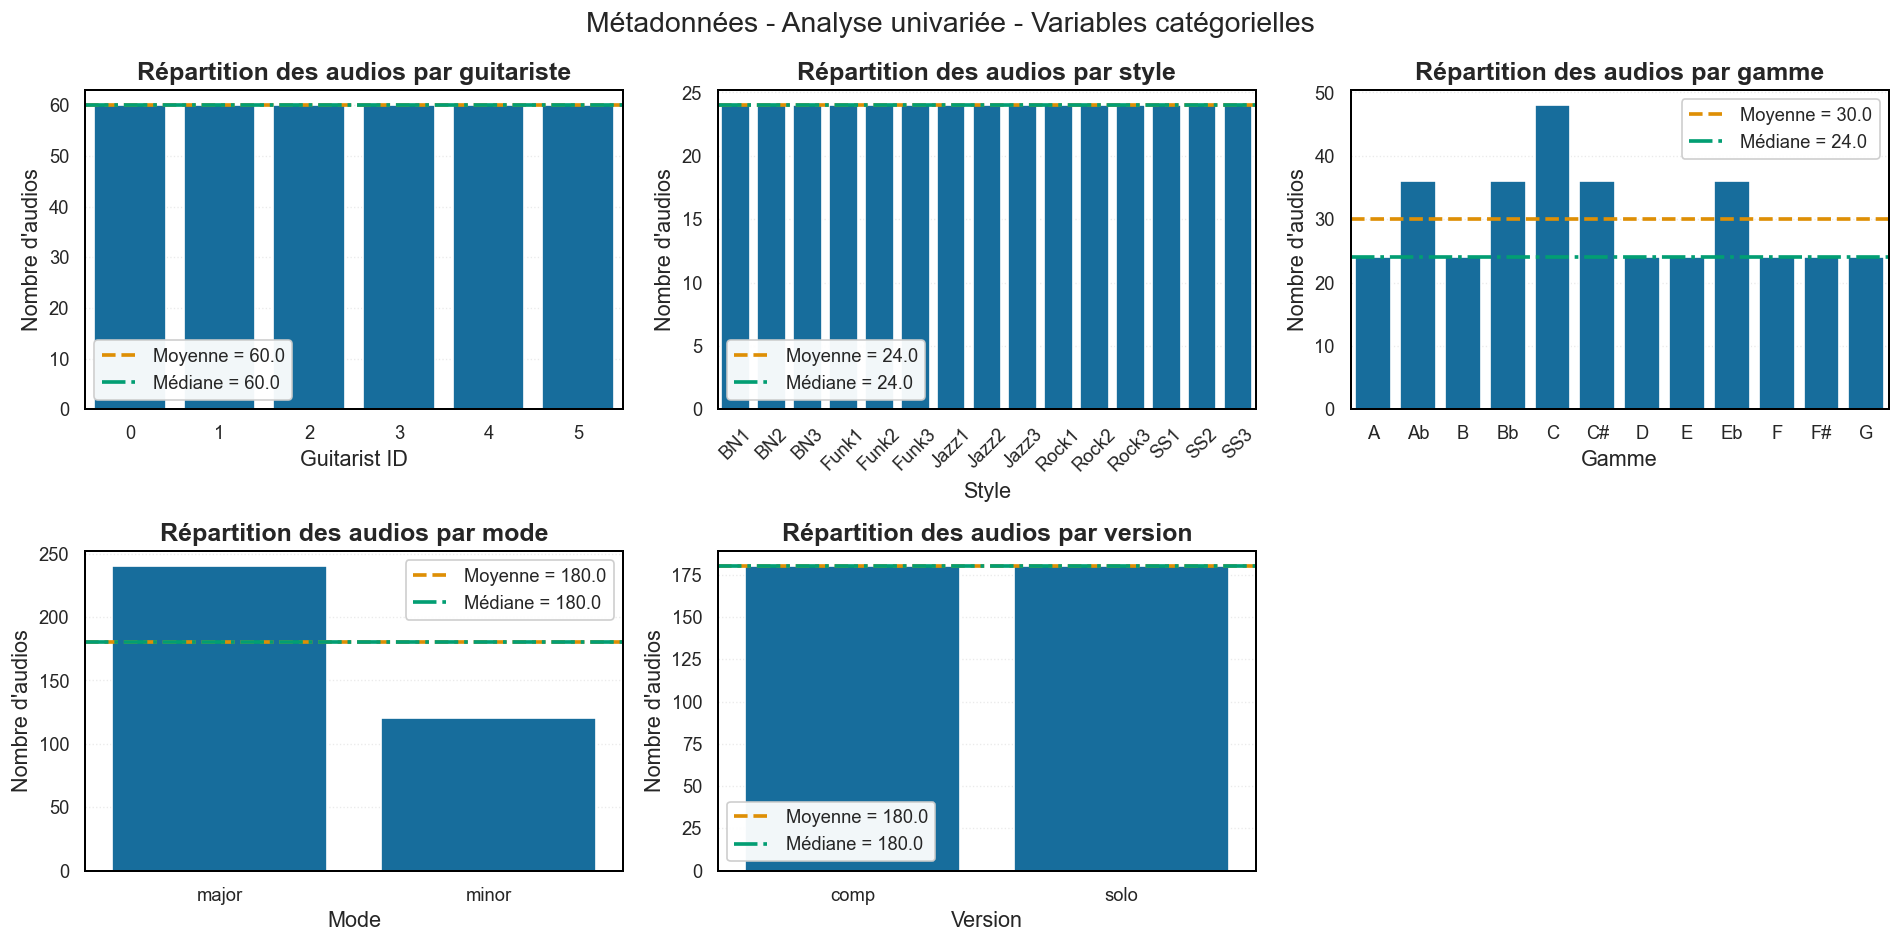

In [8]:
def create_barplot(ax, df, column, rotation=0):
    df_grpby = df.groupby(column).agg(size=(column, "size")).reset_index()

    sns.barplot(
        data=df_grpby,
        x=column,
        y="size",
        ax=ax,
    )

    mean_column = df_grpby["size"].mean()
    median_column = df_grpby["size"].median()

    ax.axhline(
        mean_column,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        label=f"Moyenne = {mean_column:.1f}",
    )

    ax.axhline(
        median_column,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        label=f"Médiane = {median_column:.1f}",
    )

    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)

    if rotation:
        ax.tick_params(axis="x", rotation=rotation)


fig, axes = plt.subplots(2, 3, figsize=(16, 8))

fig.suptitle("Métadonnées - Analyse univariée - Variables catégorielles", fontsize=17)

# ===
# Répartition des audios par guitarist_id
# ===
ax1 = axes[0, 0]
create_barplot(ax=ax1, df=df_metadata, column="guitarist_id")
ax1.set_title("Répartition des audios par guitariste")
ax1.set_xlabel("Guitarist ID")
ax1.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par style
# ===
ax2 = axes[0, 1]
create_barplot(ax=ax2, df=df_metadata, column="style", rotation=45)
ax2.set_title("Répartition des audios par style")
ax2.set_xlabel("Style")
ax2.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par scale
# ===
ax3 = axes[0, 2]
create_barplot(ax=ax3, df=df_metadata, column="scale")
ax3.set_title("Répartition des audios par gamme")
ax3.set_xlabel("Gamme")
ax3.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par mode
# ===
ax4 = axes[1, 0]
create_barplot(ax=ax4, df=df_metadata, column="mode")
ax4.set_title("Répartition des audios par mode")
ax4.set_xlabel("Mode")
ax4.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par playing_version
# ===
ax5 = axes[1, 1]
create_barplot(ax=ax5, df=df_metadata, column="playing_version")
ax5.set_title("Répartition des audios par version")
ax5.set_xlabel("Version")
ax5.set_ylabel("Nombre d'audios")

axes[1, 2].set_axis_off()

fig.tight_layout()
plt.savefig(
    (FIGURES_DIRECTORY / "metadata_categorical_variables_distributions.png").as_posix()
)
plt.show()

In [9]:
df_mode = df_metadata["mode"].value_counts()
print("Répartition des audios par mode :")
for mode in df_mode.index:
    print(
        f"  Pourcentage d'audio en mode {mode} : {df_mode.loc[mode] / df_mode.sum() * 100:.2f}%"
    )

df_scale = df_metadata["scale"].value_counts()
print("\nRépartition des audios par scale :")
for scale in df_scale.index:
    print(
        f"  Pourcentage d'audio en gamme {scale} : {df_scale.loc[scale] / df_scale.sum() * 100:.2f}%"
    )

Répartition des audios par mode :
  Pourcentage d'audio en mode major : 66.67%
  Pourcentage d'audio en mode minor : 33.33%

Répartition des audios par scale :
  Pourcentage d'audio en gamme C : 13.33%
  Pourcentage d'audio en gamme Eb : 10.00%
  Pourcentage d'audio en gamme Ab : 10.00%
  Pourcentage d'audio en gamme C# : 10.00%
  Pourcentage d'audio en gamme Bb : 10.00%
  Pourcentage d'audio en gamme F# : 6.67%
  Pourcentage d'audio en gamme B : 6.67%
  Pourcentage d'audio en gamme G : 6.67%
  Pourcentage d'audio en gamme E : 6.67%
  Pourcentage d'audio en gamme A : 6.67%
  Pourcentage d'audio en gamme D : 6.67%
  Pourcentage d'audio en gamme F : 6.67%


Observations :
- Les varaibles `guitarist_id`, `style` et `playing_version` sont équiréparties.
- La répartition de la varaible `scale` est n'est pas uniforme et a pour mode `C` (Gamme de Do) regroupant environ 13% des audios.
- La répartition de la variable `mode` est déséquilibrée et a pour mode `major` (gamme majeure) regroupant envirion 67% des audios.

Hypothèse :
- Le déséquilibre de la classe `mode` peut avoir un impact sur l'apprentissage et devrait être considéré lors de la division du dataset en jeu d'entraînement et jeu de test.

In [10]:
def compute_cramers_v(x: pd.Series, y: pd.Series) -> float:
    contingency_table = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))


def compute_contingency_pearson(x: pd.Series, y: pd.Series) -> float:
    contingency_table = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    return np.sqrt(chi2 / (n + chi2))


def compute_tschuprow(x: pd.Series, y: pd.Series) -> float:
    contingency_table = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * np.sqrt((k - 1) * (r - 1))))


METHODS: dict[str, Callable] = {
    "cramers_v": compute_cramers_v,
    "contingency_pearson": compute_contingency_pearson,
    "tschuprow": compute_tschuprow,
}


def compute_cat_corr_df(
    df: pd.DataFrame, cat_vars: list, method: str = "cramers_v"
) -> pd.DataFrame:
    method = METHODS.get(method, None)
    if method is None:
        raise ValueError(f"method accepted: {list(METHODS.keys())}")
    cat_corr_mat = np.zeros((len(cat_vars), len(cat_vars)))
    for i in range(len(cat_vars)):
        for j in range(len(cat_vars)):
            cat_corr_mat[i, j] = method(
                df_metadata[cat_vars[i]], df_metadata[cat_vars[j]]
            )
    return pd.DataFrame(cat_corr_mat)


cat_vars = ["guitarist_id", "style", "scale", "mode", "playing_version"]
cat_corr_df = compute_cat_corr_df(df=df_metadata, cat_vars=cat_vars, method="cramers_v")

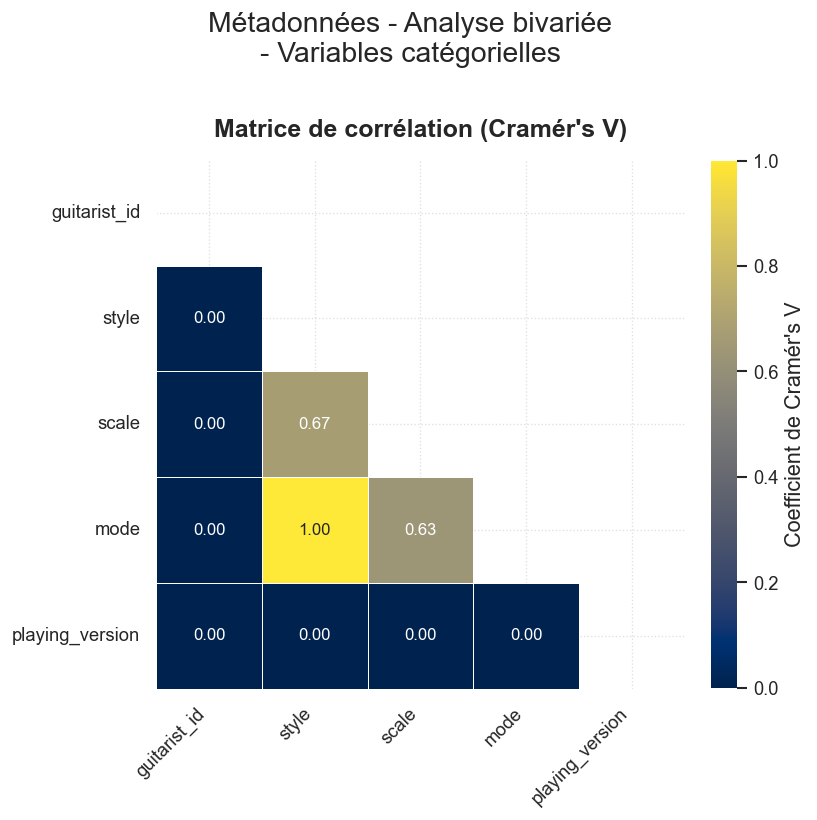

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))

fig.suptitle("Métadonnées - Analyse bivariée\n- Variables catégorielles", fontsize=17)

heatmap = sns.heatmap(
    cat_corr_df,
    mask=np.triu(np.ones_like(cat_corr_df, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Cramér's V"},
    annot_kws={"size": 10},
    ax=ax,
)
ax.set_title("Matrice de corrélation (Cramér's V)", pad=14)
ax.set_xticklabels(cat_vars, rotation=45, ha="right")
ax.set_yticklabels(cat_vars, rotation=0)

plt.tight_layout()
plt.savefig(
    (
        FIGURES_DIRECTORY / "metadata_categorical_variables_correlation_matrix.png"
    ).as_posix()
)
plt.show()

Observations :
- Corrélation forte entre `mode` et `style`.
- Corrélation modérée entre `scale` et `style` et entre `mode` et `scale`.
- `playing_version` et `guitarist_id` ne présente aucune corrélation avec les autres variables qualitatives.

Hypothèses :
- Chaque style semble associé un mode (majeur ou mineur).
- Certaines gammes semblent préférentiellement associées à un mode (majeur ou mineur).

### Variables numériques

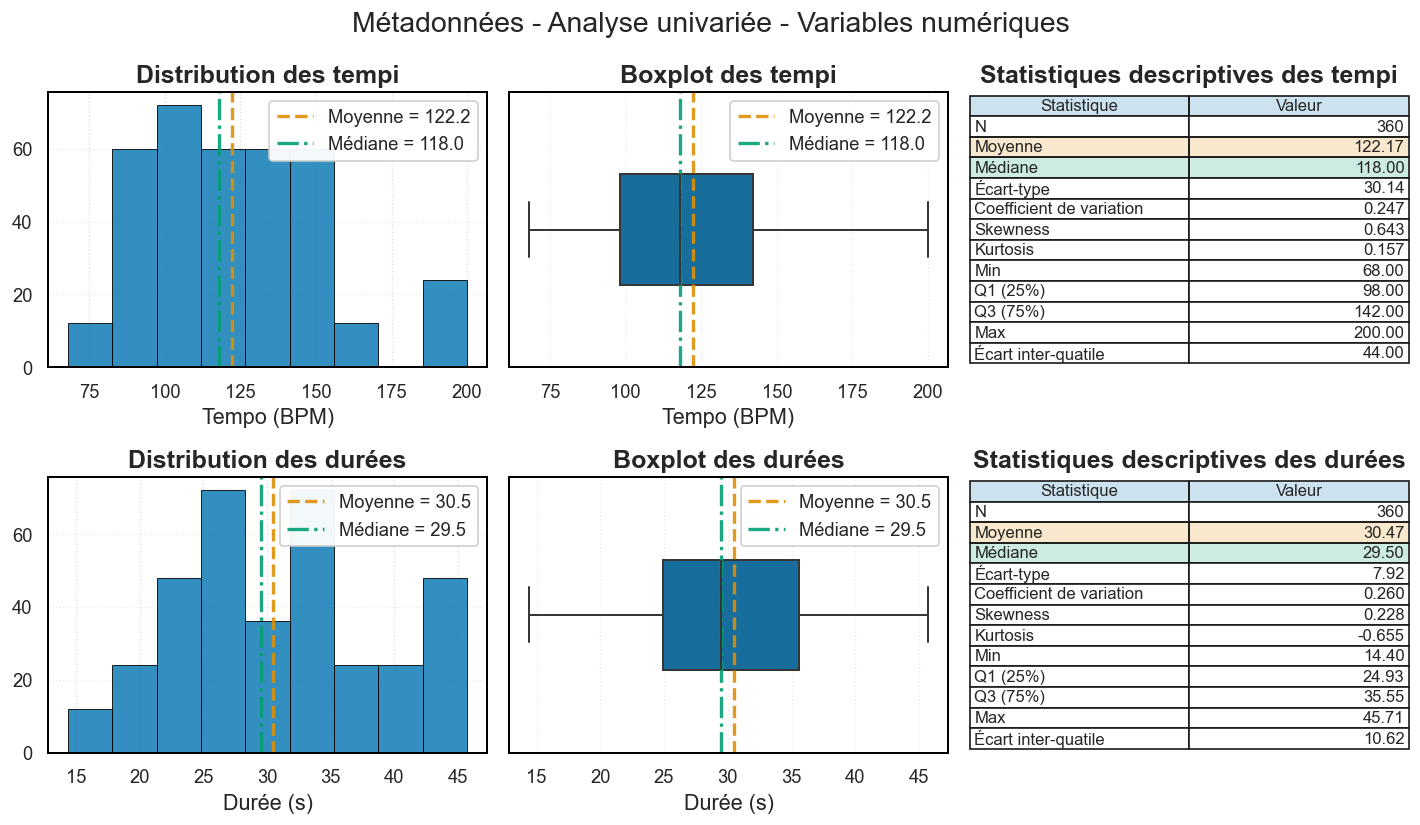

In [12]:
def create_histplot(ax, df, column):
    values = df[column].dropna()

    sns.histplot(
        x=values,
        # bins=int(np.sqrt(len(values))),
        bins=int(1 + np.log2(len(values))),
        color=COLORBLIND_PALETTE[0],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.8,
        ax=ax,
    )

    mean_column = values.mean()
    median_column = values.median()

    ax.axvline(
        mean_column,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_column:.1f}",
    )

    ax.axvline(
        median_column,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_column:.1f}",
    )

    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)


def create_boxplot(ax, df, column):
    values = df[column].dropna()

    sns.boxplot(
        x=values,
        ax=ax,
        color=COLORBLIND_PALETTE[0],
        width=0.4,
        fliersize=4,
        linewidth=1.2,
    )

    mean_val = values.mean()
    median_val = values.median()

    ax.axvline(
        mean_val,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_val:.1f}",
    )

    ax.axvline(
        median_val,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_val:.1f}",
    )

    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)


def create_stats_panel(ax, df, column):
    values = df[column].dropna()

    mean_val = values.mean()
    std_val = values.std()
    cv = std_val / mean_val if mean_val != 0 else np.nan
    skew = values.skew()
    kurt = values.kurtosis()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    stats_data = [
        ["N", f"{len(values)}"],
        ["Moyenne", f"{mean_val:.2f}"],
        ["Médiane", f"{values.median():.2f}"],
        ["Écart-type", f"{std_val:.2f}"],
        ["Coefficient de variation", f"{cv:.3f}"],
        ["Skewness", f"{skew:.3f}"],
        ["Kurtosis", f"{kurt:.3f}"],
        ["Min", f"{values.min():.2f}"],
        ["Q1 (25%)", f"{q1:.2f}"],
        ["Q3 (75%)", f"{q3:.2f}"],
        ["Max", f"{values.max():.2f}"],
        ["Écart inter-quatile", f"{q3 - q1:.2f}"],
    ]

    table = ax.table(
        cellText=stats_data,
        colLabels=["Statistique", "Valeur"],
        cellLoc="right",
        colLoc="center",
        loc="center",
    )

    # Style
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.1)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor(COLORBLIND_PALETTE[0] + (0.2,))
        else:
            cell.PAD = 0.02
            if col == 0:
                cell.get_text().set_ha("left")
        if row == 2:
            cell.set_facecolor(COLORBLIND_PALETTE[1] + (0.2,))
        if row == 3:
            cell.set_facecolor(COLORBLIND_PALETTE[2] + (0.2,))

    ax.set_axis_off()


fig, axes = plt.subplots(2, 3, figsize=(12, 7))

fig.suptitle("Métadonnées - Analyse univariée - Variables numériques", fontsize=17)

# ===
# Distribution des tempi
# ===
ax1 = axes[0, 0]
create_histplot(ax=ax1, df=df_metadata, column="tempo")
ax1.set_title("Distribution des tempi")
ax1.set_xlabel("Tempo (BPM)")
ax1.set_ylabel(None)

ax2 = axes[0, 1]
create_boxplot(ax2, df_metadata, "tempo")
ax2.set_title("Boxplot des tempi")
ax2.set_xlabel("Tempo (BPM)")

ax3 = axes[0, 2]
create_stats_panel(ax3, df_metadata, "tempo")
ax3.set_title("Statistiques descriptives des tempi")

# ===
# Distribution des durée
# ===
ax4 = axes[1, 0]
create_histplot(ax=ax4, df=df_metadata, column="duration")
ax4.set_title("Distribution des durées")
ax4.set_xlabel("Durée (s)")
ax4.set_ylabel(None)

ax5 = axes[1, 1]
create_boxplot(ax5, df_metadata, "duration")
ax5.set_title("Boxplot des durées")
ax5.set_xlabel("Durée (s)")

ax6 = axes[1, 2]
create_stats_panel(ax6, df_metadata, "duration")
ax6.set_title("Statistiques descriptives des durées")

fig.tight_layout()
plt.savefig(
    (FIGURES_DIRECTORY / "metadata_numerical_variables_distributions.png").as_posix()
)
plt.show()

Observations :
- **tempo**
  - Les tempi varient de 68bpm à 200bpm, présentant une étendue de 132bpm.
  - La moyenne est légérement supérieure à la médiane, ce qui indique une légère asymétrie positive (à droite).
  - Au moins la moitié des tempi sont inférieurs ou égaux à 118bpm. Quelques valeurs élevées influencent légèrement la moyenne.
  - Le coefficient de variation de $\dfrac{\bar{s}}{\bar{x}}\times 100 \simeq 24.7$% indique une dispersion modérée.
  - Au moins la moitié des tempi sont compris entre Q1=98bpm et Q3=142bpm présentant un intervalle inter-quartile de 44bpm.
  - L’intervalle inter-quartile est raisonnable par rapport à la moyenne $\dfrac{IQR}{\bar{x}} \simeq 36$%.
  - Le rapport IQR sur écart-type de $\dfrac{IQR}{\bar{s}} \simeq 1.46$% est légérement supérieur à 1.35, indiquant une légère concentration centrale, une distribution légérement pointue, la possibilité d’une distribution leptokurtique.
  - Le skewness de 0.643 confirme une asymétrique positive modérée.
  - Le kurtosis de 0.157 confirme une distribution légérement leptokurtique.
  - Pas de outlier apparant par la méthode de Turkey, $Q1 - 1.5\times IQR = 32$ et $Q3 + 1.5\times IQR = 208$.
  - La variabilité provient surtout de la dispersion générale plutôt que d’extrêmes très isolés.

- **duration**
  - Les durées varient de 14.4s à 45.71s, présentant une étendue de 31,31s.
  - La moyenne est légérement supérieure à la médiane, ce qui indique une légère asymétrie positive (à droite).
  - Au moins la moitié des durée sont inférieures ou égales à 29.5s. Quelques valeurs élevées influencent légèrement la moyenne.
  - Le coefficient de variation de $\dfrac{\bar{s}}{\bar{x}}\times 100 \simeq 26$% indique une dispersion modérée.
  - Au moins la moitié des durées sont comprises entre Q1=24.93s et Q3=35.55s présentant un intervalle inter-quartile de 10.62s.
  - L’intervalle inter-quartile est raisonnable par rapport à la moyenne $\dfrac{IQR}{\bar{x}} \simeq 34,85$%.
  - Le rapport IQR sur écart-type de $\dfrac{IQR}{\bar{s}} \simeq 1.34$% est très proche de 1.35, indiquant une distribution compatible avec une normale, l'absence d'effet extrême majeur, une dispersion homogène.
  - Le skewness de 0.228 confirme une faible asymétrie positive, proche de la symétrie.
  - Le kurtosis de -0.655 indique une distribution platykurtique.
  - Pas de outlier apparant par la méthode de Turkey, $Q1 - 1.5\times IQR = 9$ et $Q3 + 1.5\times IQR = 51.48$.
  - La variabilité provient surtout de la dispersion générale plutôt que d’extrêmes très isolés.

Conclusion :
- Les conditions sont favorables à une analyse de corrélation :
  - absence d'outliers
  - ditributions symétriques
  - dispersions non pathologiques
  - kurtosis raisonnables

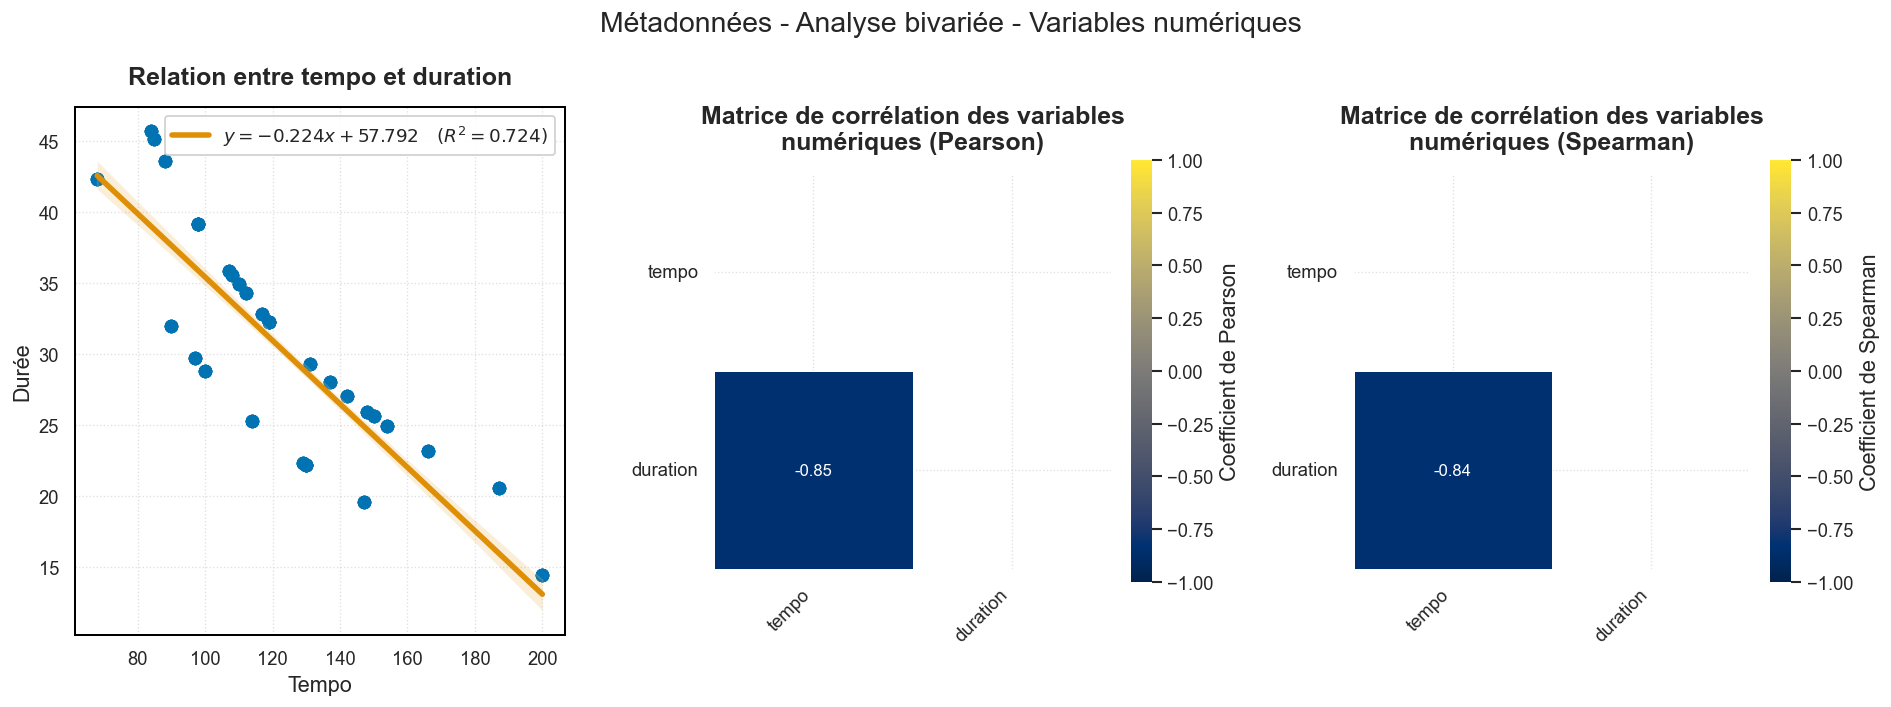

In [13]:
num_vars = ["tempo", "duration"]
num_corr_df_pearson = df_metadata[num_vars].corr(method="pearson")
num_corr_df_spearman = df_metadata[num_vars].corr(method="spearman")

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

fig.suptitle("Métadonnées - Analyse bivariée - Variables numériques", fontsize=17)

# ===
# Heatmap matrice de corrélation
# ===
ax1 = axes[1]
heatmap = sns.heatmap(
    num_corr_df_pearson,
    mask=np.triu(np.ones_like(num_corr_df_pearson, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Pearson"},
    annot_kws={"size": 10},
    ax=ax1,
)
ax1.set_title("Matrice de corrélation des variables\nnumériques (Pearson)", pad=14)
ax1.set_xticklabels(num_vars, rotation=45, ha="right")
ax1.set_yticklabels(num_vars, rotation=0)

# ===
# Heatmap matrice de corrélation
# ===
ax2 = axes[2]
heatmap = sns.heatmap(
    num_corr_df_spearman,
    mask=np.triu(np.ones_like(num_corr_df_spearman, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Spearman"},
    annot_kws={"size": 10},
    ax=ax2,
)
ax2.set_title("Matrice de corrélation des variables\nnumériques (Spearman)", pad=14)
ax2.set_xticklabels(num_vars, rotation=45, ha="right")
ax2.set_yticklabels(num_vars, rotation=0)

# ===
# Scatterplot tempo vs duration
# ===
ax3 = axes[0]

x = df_metadata["tempo"].values
y = df_metadata["duration"].values
a, b = np.polyfit(x, y, 1)
r2 = np.corrcoef(x, y)[0, 1] ** 2
equation = (
    rf"$y = {a:.3f}x {'+' if b >= 0 else '-'} {abs(b):.3f}\quad (R^2 = {r2:.3f})$"
)

sns.regplot(
    data=df_metadata,
    x="tempo",
    y="duration",
    order=1,
    scatter_kws={"color": COLORBLIND_PALETTE[0]},
    line_kws={"color": COLORBLIND_PALETTE[1], "label": equation},
    ax=ax3,
)
ax3.set_title("Relation entre tempo et duration", pad=14)
ax3.set_xlabel("Tempo")
ax3.set_ylabel("Durée")
ax3.legend()

plt.tight_layout()
plt.savefig(
    (
        FIGURES_DIRECTORY / "metadata_numerical_variables_correlation_matrix.png"
    ).as_posix()
)
plt.show()

Observation :
- Forte corrélation négative entre `tempo` et `duration` avec un coefficient de Pearson de -0.85 et un coefficient de Spearman de -0.84.
- La proximité des coefficients de Pearson et de Spearman ainsi qu'un $R^2=0.724$ montre que la relaltion entre `tempo` et `duration` est raisonnablement linéaire.

Hypothèses :
- Les morceaux avec un tempo rapide semblent plus courts que les morceaux avec un tempo lent.

### Corrélations entre variables catégorielles et numériques

In [14]:
def calculate_eta2(categories: pd.Series, values: pd.Series) -> float:
    mask = ~pd.isna(categories) & ~pd.isna(values)
    categories = pd.Categorical(categories[mask])
    values = values[mask]

    means = values.groupby(categories).mean()
    n = values.groupby(categories).count()
    total_mean = values.mean()

    inter_categorical_variance = 1 / n.sum() * (n * (means - total_mean) ** 2).sum()
    total_variance = 1 / n.sum() * ((values - total_mean) ** 2).sum()
    return inter_categorical_variance / total_variance


def compute_cat_num_corr_df(
    df: pd.DataFrame, cat_vars: list, num_vars: list
) -> pd.DataFrame:
    eta2_dict = {}
    for cat_var in cat_vars:
        eta2_dict[cat_var] = {}
        for num_var in num_vars:
            eta2_dict[cat_var][num_var] = calculate_eta2(df[cat_var], df[num_var])
    eta2_df = pd.DataFrame(eta2_dict).T[num_vars]
    return eta2_df


cat_num_corr_df = compute_cat_num_corr_df(df_metadata, cat_vars, num_vars)

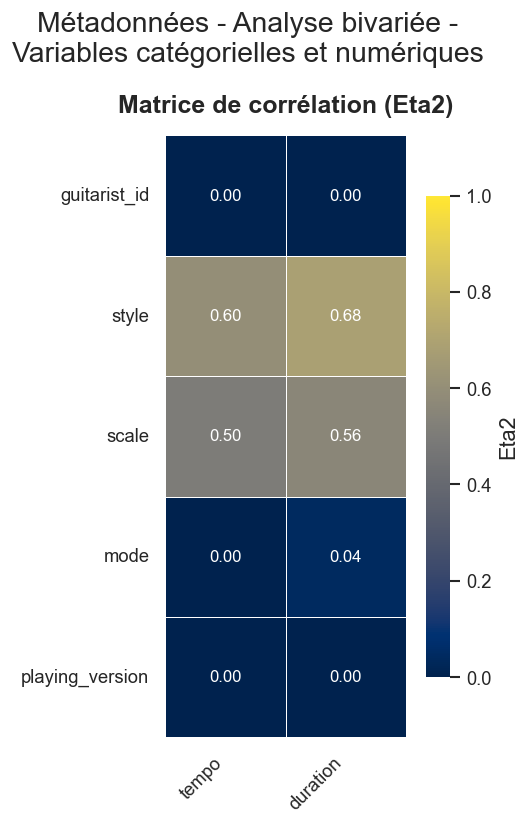

In [15]:
fig, ax = plt.subplots(figsize=(5, 7))

fig.suptitle(
    "Métadonnées - Analyse bivariée -\nVariables catégorielles et numériques",
    fontsize=17,
)

heatmap = sns.heatmap(
    cat_num_corr_df,
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Eta2"},
    annot_kws={"size": 10},
    ax=ax,
)
ax.set_title(
    "Matrice de corrélation (Eta2)",
    pad=14,
)
ax.set_xticklabels(num_vars, rotation=45, ha="right")
ax.set_yticklabels(cat_vars, rotation=0)

plt.tight_layout()
plt.savefig(
    (
        FIGURES_DIRECTORY
        / "metadata_categorical_and_numerical_variables_correlation_matrix.png"
    ).as_posix()
)
plt.show()

Observations :
- Corrélation modérée entre `style` et `tempo` et entre `style` et `duration`.
- Corrélation modérée entre `scale` et `tempo` et entre `scale` et `duration`.
- Absence de corrélation entre `guitarist_id`, `mode`, `playing_version` et `tempo` et entre `guitarist_id`, `mode`, `playing_version` et `duration`.

Hypothèses :
- Les styles musicaux semblent avoir des tempo et durées différents.
- Les gammes semblent jouées à des tempo différents et sur des durées différentes.

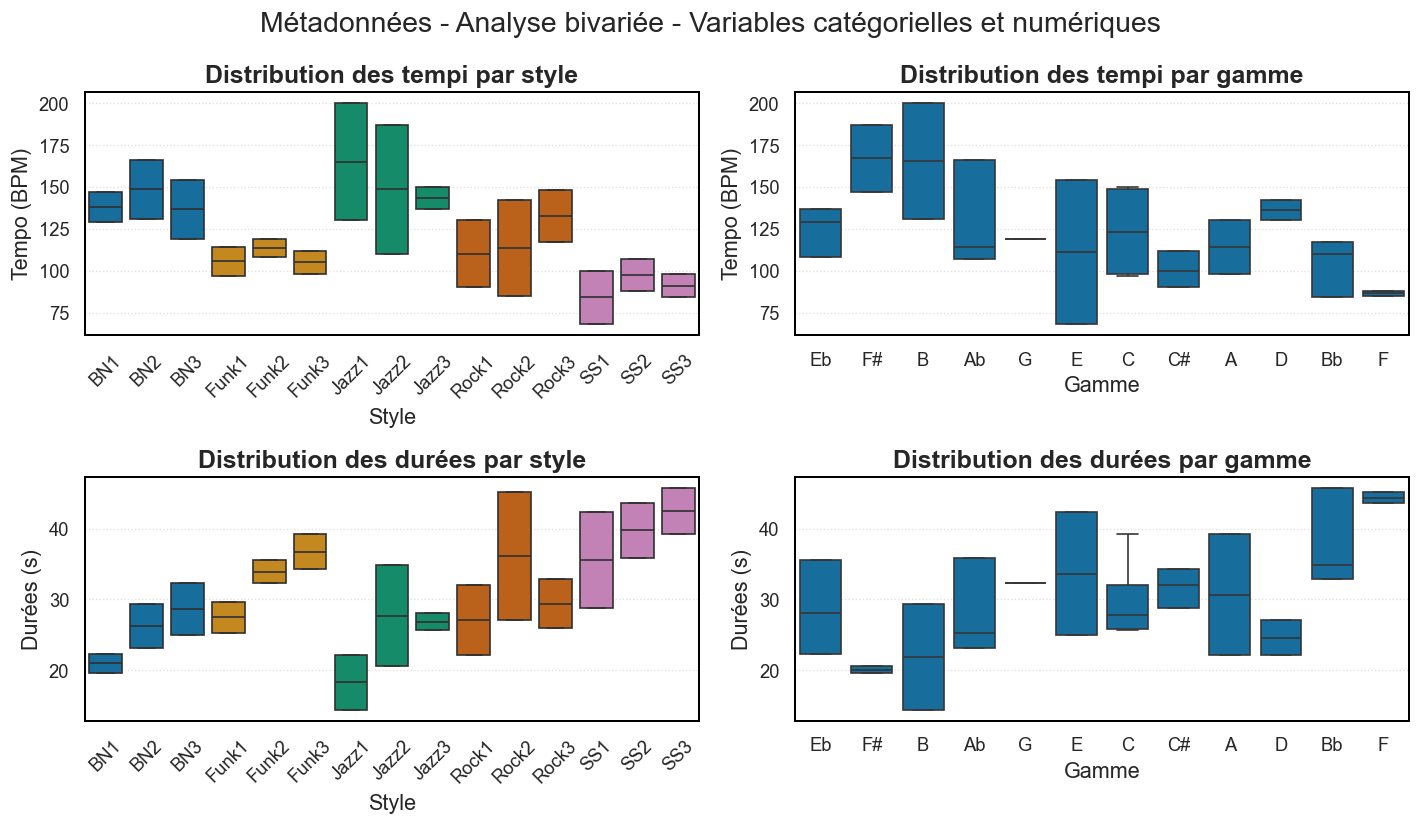

In [16]:
df_metadata["style_group"] = df_metadata["style"].str.replace(r"\d+", "", regex=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

fig.suptitle(
    "Métadonnées - Analyse bivariée - Variables catégorielles et numériques",
    fontsize=17,
)

# ===
# Boxplot Tempo vs Style
# ===
ax1 = axes[0, 0]
sns.boxplot(
    data=df_metadata,
    x="style",
    y="tempo",
    palette="colorblind",
    hue="style_group",
    legend=False,
    ax=ax1,
)
ax1.set_title("Distribution des tempi par style")
ax1.tick_params(axis="x", rotation=45)
ax1.set_xlabel("Style")
ax1.set_ylabel("Tempo (BPM)")

# ===
# Boxplot Tempo vs Scale
# ===
ax2 = axes[0, 1]
sns.boxplot(
    data=df_metadata,
    x="scale",
    y="tempo",
    color=COLORBLIND_PALETTE[0],
    ax=ax2,
)
ax2.set_title("Distribution des tempi par gamme")
ax2.set_xlabel("Gamme")
ax2.set_ylabel("Tempo (BPM)")

# ===
# Boxplot Duration vs Style
# ===
ax3 = axes[1, 0]
sns.boxplot(
    data=df_metadata,
    x="style",
    y="duration",
    palette="colorblind",
    hue="style_group",
    legend=False,
    ax=ax3,
)
ax3.set_title("Distribution des durées par style")
ax3.tick_params(axis="x", rotation=45)
ax3.set_xlabel("Style")
ax3.set_ylabel("Durées (s)")

# ===
# Boxplot Duration vs Scale
# ===
ax4 = axes[1, 1]
sns.boxplot(
    data=df_metadata,
    x="scale",
    y="duration",
    color=COLORBLIND_PALETTE[0],
    ax=ax4,
)
ax4.set_title("Distribution des durées par gamme")
ax4.set_xlabel("Gamme")
ax4.set_ylabel("Durées (s)")

plt.tight_layout()
plt.savefig(
    (
        FIGURES_DIRECTORY / "metadata_categorical_and_numerical_variables_boxplots.png"
    ).as_posix()
)
plt.show()

Observations :
- Distribution des `tempi` par `style` :
  - Les styles présentent des profils rythmiques distincts. *Jazz* et *Rock* montrent une variabilité importante du tempo, tandis que *BN*, *Funk* et *SS* sont relativement stables.
  - *Funk* et *SS* tendent vers des tempi plus lents.
  - Le dataset semble couvrir un spectre rythmique large.
- Distribution des `tempi` par `gamme` :
  - La distribution des tempi ne semble pas dépendre de la tonalité, aucune tendance n’apparaît.
- Distribution des `durees` par `style` :
  - Les styles influencent la durée des extraits. *Jazz* contient généralement les morceaux les plus courts, alors que *SS* et *Rock* présentent des durées plus longues.
- Distribution des `durees` par `gamme` :
  - La distribution des durées ne semble pas dépendre de la tonalité, aucune tendance n’apparaît.


## Annotations (MongoDB)

In [17]:
pipeline = [
    {"$match": {"dataset_name": "GuitarSet"}},
    {"$count": "*"},
]

collection = "note_midi"
print(
    f"Nombre de documents dans la collection {collection} :",
    mongo.aggregate_documents(collection_name=collection, pipeline=pipeline)[0].get(
        "*", "ERROR"
    ),
)

Nombre de documents dans la collection note_midi : 360


In [18]:
pipeline = [{"$match": {"dataset_name": "GuitarSet"}}]

title_annotations = mongo.aggregate_documents(
    collection_name="note_midi", pipeline=pipeline
)
df_annotation = pd.DataFrame(title_annotations)[["title", "note_midi"]]

df_annotation = df_annotation.explode("note_midi").reset_index(drop=True)
df_annotation = df_annotation.join(pd.json_normalize(df_annotation["note_midi"]))
df_annotation = df_annotation.drop(columns="note_midi")

df_annotation["data_source"] = df_annotation["data_source"].astype("int")

df_annotation.head()

,title,data_source,time,duration,value
0,00_BN1-129-Eb_comp,0,7.457274,0.464399,44.018917
1,00_BN1-129-Eb_comp,0,7.923578,0.922993,44.224918
2,00_BN1-129-Eb_comp,0,8.870789,0.191565,44.106065
3,00_BN1-129-Eb_comp,0,14.834689,0.487619,46.053185
4,00_BN1-129-Eb_comp,0,15.333215,1.416417,46.071249


In [19]:
df_annotation.info()

<class 'pandas.DataFrame'>
RangeIndex: 62476 entries, 0 to 62475
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        62476 non-null  str    
 1   data_source  62476 non-null  int64  
 2   time         62476 non-null  float64
 3   duration     62476 non-null  float64
 4   value        62476 non-null  float64
dtypes: float64(3), int64(1), str(1)
memory usage: 3.5 MB


Observations :
- Ni valeur nulle, ni valeur manquante.
- Présence de variables numériques uniquement, les titres étant considérés comme des identifiants.

In [20]:
STRINGS_MAP = {0: "E2", 1: "A2", 2: "D3", 3: "G3", 4: "B3", 5: "E4"}

STRING_ORDER = ["E2", "A2", "D3", "G3", "B3", "E4"]

df_annotation["string"] = df_annotation["data_source"].map(STRINGS_MAP)

In [21]:
pitch_range_per_string = (
    df_annotation.groupby("string")
    .agg(
        min_pitch=("value", "min"),
        max_pitch=("value", "max"),
    )
    .sort_values("min_pitch")
    .reset_index()
)

theoretical_pitch_range_per_string = pd.DataFrame(
    {
        "string": ["E2", "A2", "D3", "G3", "B3", "E4"],
        "theoretical_min_pitch": [40, 45, 50, 55, 59, 64],
        "theoretical_max_pitch": [59, 64, 69, 74, 78, 83],
    }
)

pitch_ranges = pitch_range_per_string.merge(
    theoretical_pitch_range_per_string, on="string", how="left"
)

pitch_ranges.style.hide(axis="index").format(
    decimal=",", thousands=" ", precision=2
).to_latex(buf=LATEX_DIRECTORY / "pitch_ranges.tex")

pitch_ranges[
    [
        "string",
        "min_pitch",
        "theoretical_min_pitch",
        "max_pitch",
        "theoretical_max_pitch",
    ]
].head(6).round(2)

,string,min_pitch,theoretical_min_pitch,max_pitch,theoretical_max_pitch
0,E2,39.79,40,54.01,59
1,A2,44.68,45,58.06,64
2,D3,49.75,50,69.10,69
3,G3,54.63,55,73.09,74
4,B3,58.60,59,78.39,78
5,E4,63.58,64,80.98,83


Remarque :
- La guitare utilisée dans le dataset GuitarSet comporte 19 frettes. Le pitch théorique maximal est donc la somme du pitch théorique minimal et de 19.

Observation :
- On observe que les intervalles de pitch réels et théoriques coincident. Pas d'anomalie détectée.

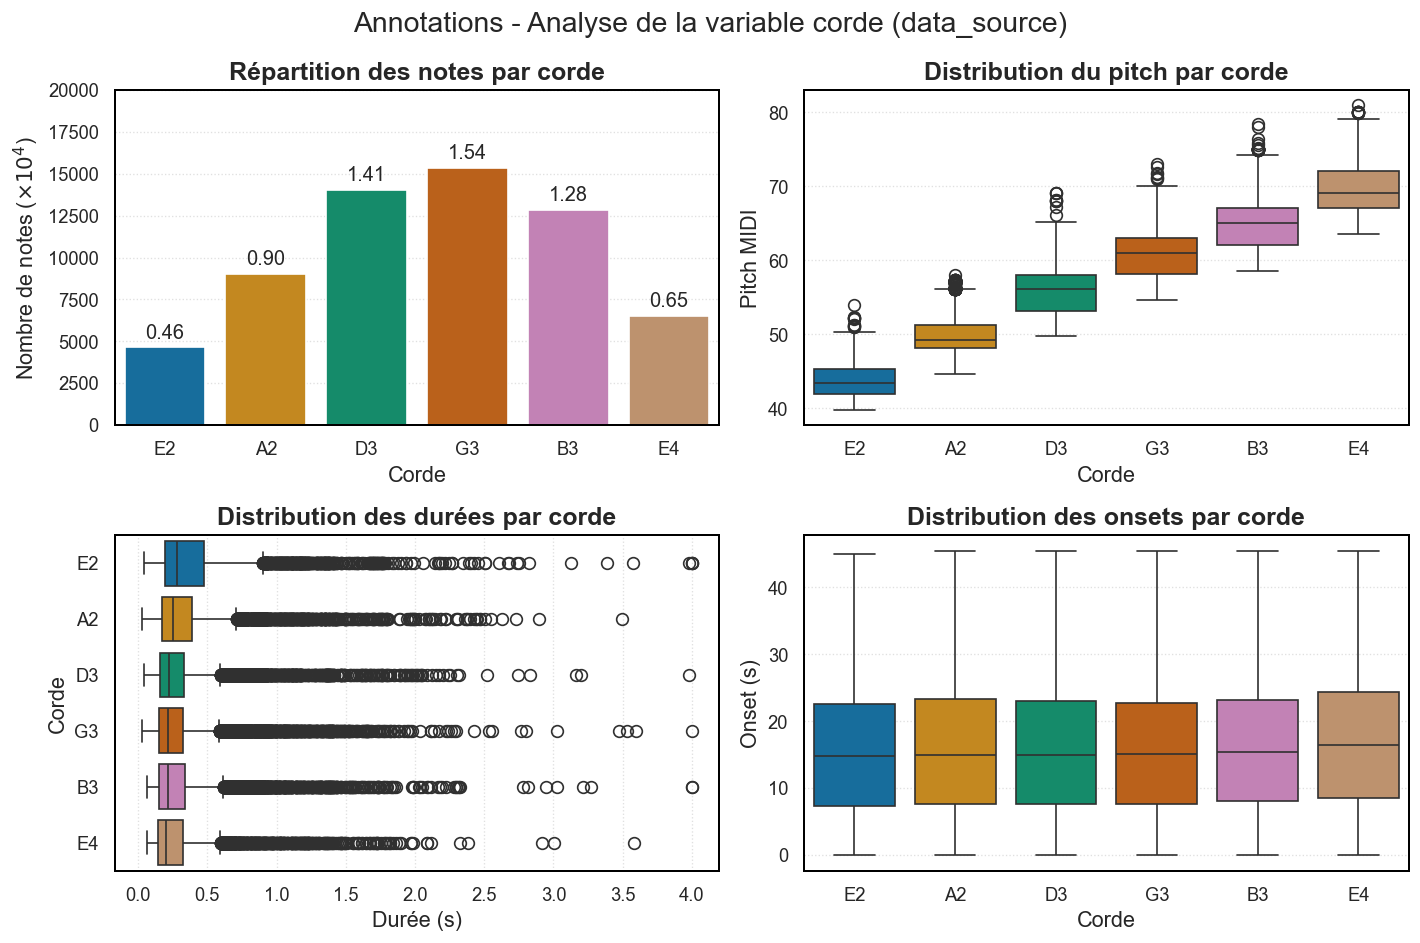

In [22]:
notes_per_string = df_annotation.groupby("string")["time"].count().reindex(STRING_ORDER)

string_color = {
    "E2": COLORBLIND_PALETTE[0],
    "A2": COLORBLIND_PALETTE[1],
    "D3": COLORBLIND_PALETTE[2],
    "G3": COLORBLIND_PALETTE[3],
    "B3": COLORBLIND_PALETTE[4],
    "E4": COLORBLIND_PALETTE[5],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

fig.suptitle("Annotations - Analyse de la variable corde (data_source)", fontsize=17)

axes = axes.flatten()

# ===
# Répartition des notes par cordes
# ===
ax1 = axes[0]
barplot = sns.barplot(
    x=notes_per_string.index,
    y=notes_per_string.values,
    palette=string_color,
    hue=notes_per_string.index,
    legend=False,
    ax=ax1,
)
ax1.set_title("Répartition des notes par corde")
ax1.set_xlabel("Corde")
ax1.set_ylabel(r"Nombre de notes ($\times 10^4$)")
ax1.set_ylim(0, 2 * 10**4)

for container in barplot.containers:
    labels = [f"{v / 1e4:.2f}" for v in container.datavalues]
    barplot.bar_label(container, padding=3, labels=labels)

# ===
# Répartition des pitch (value) par cordes
# ===
ax2 = axes[1]
sns.boxplot(
    data=df_annotation,
    x="string",
    y="value",
    palette=string_color,
    hue="string",
    legend=False,
    ax=ax2,
)
ax2.set_xlabel("Corde")
ax2.set_ylabel("Pitch MIDI")
ax2.set_title("Distribution du pitch par corde")

# ===
# Répartition des durées par cordes
# ===
ax3 = axes[2]
sns.boxplot(
    data=df_annotation,
    x="duration",
    y="string",
    palette=string_color,
    hue="string",
    legend=False,
    ax=ax3,
)
ax3.set_xlabel("Durée (s)")
ax3.set_ylabel("Corde")
ax3.set_title("Distribution des durées par corde")

# ===
# Répartition des onset (time) par cordes
# ===
ax4 = axes[3]
sns.boxplot(
    data=df_annotation,
    x="string",
    y="time",
    palette=string_color,
    hue="string",
    legend=False,
    ax=ax4,
)
ax4.set_xlabel("Corde")
ax4.set_ylabel("Onset (s)")
ax4.set_title("Distribution des onsets par corde")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "annotation_data_source_analysis.png").as_posix())
plt.show()

Observations :
- La répartition des notes par corde est déséquilibrée. Il y a moins de notes sur les cordes *E2* et *E4* que sur les autres cordes.
- La répartition du pitch par corde révèle le chevauchement des notes par cordes et semble cohérent avec la physique réelle de l'instruement.
- La répartition des durées par corde montre que les notes graves ont tendance à durer plus longtemps que les notes aigües.
- La répartition des onset par corde indique que toutes les cordes semblent utilisées tout au long des morceaux.

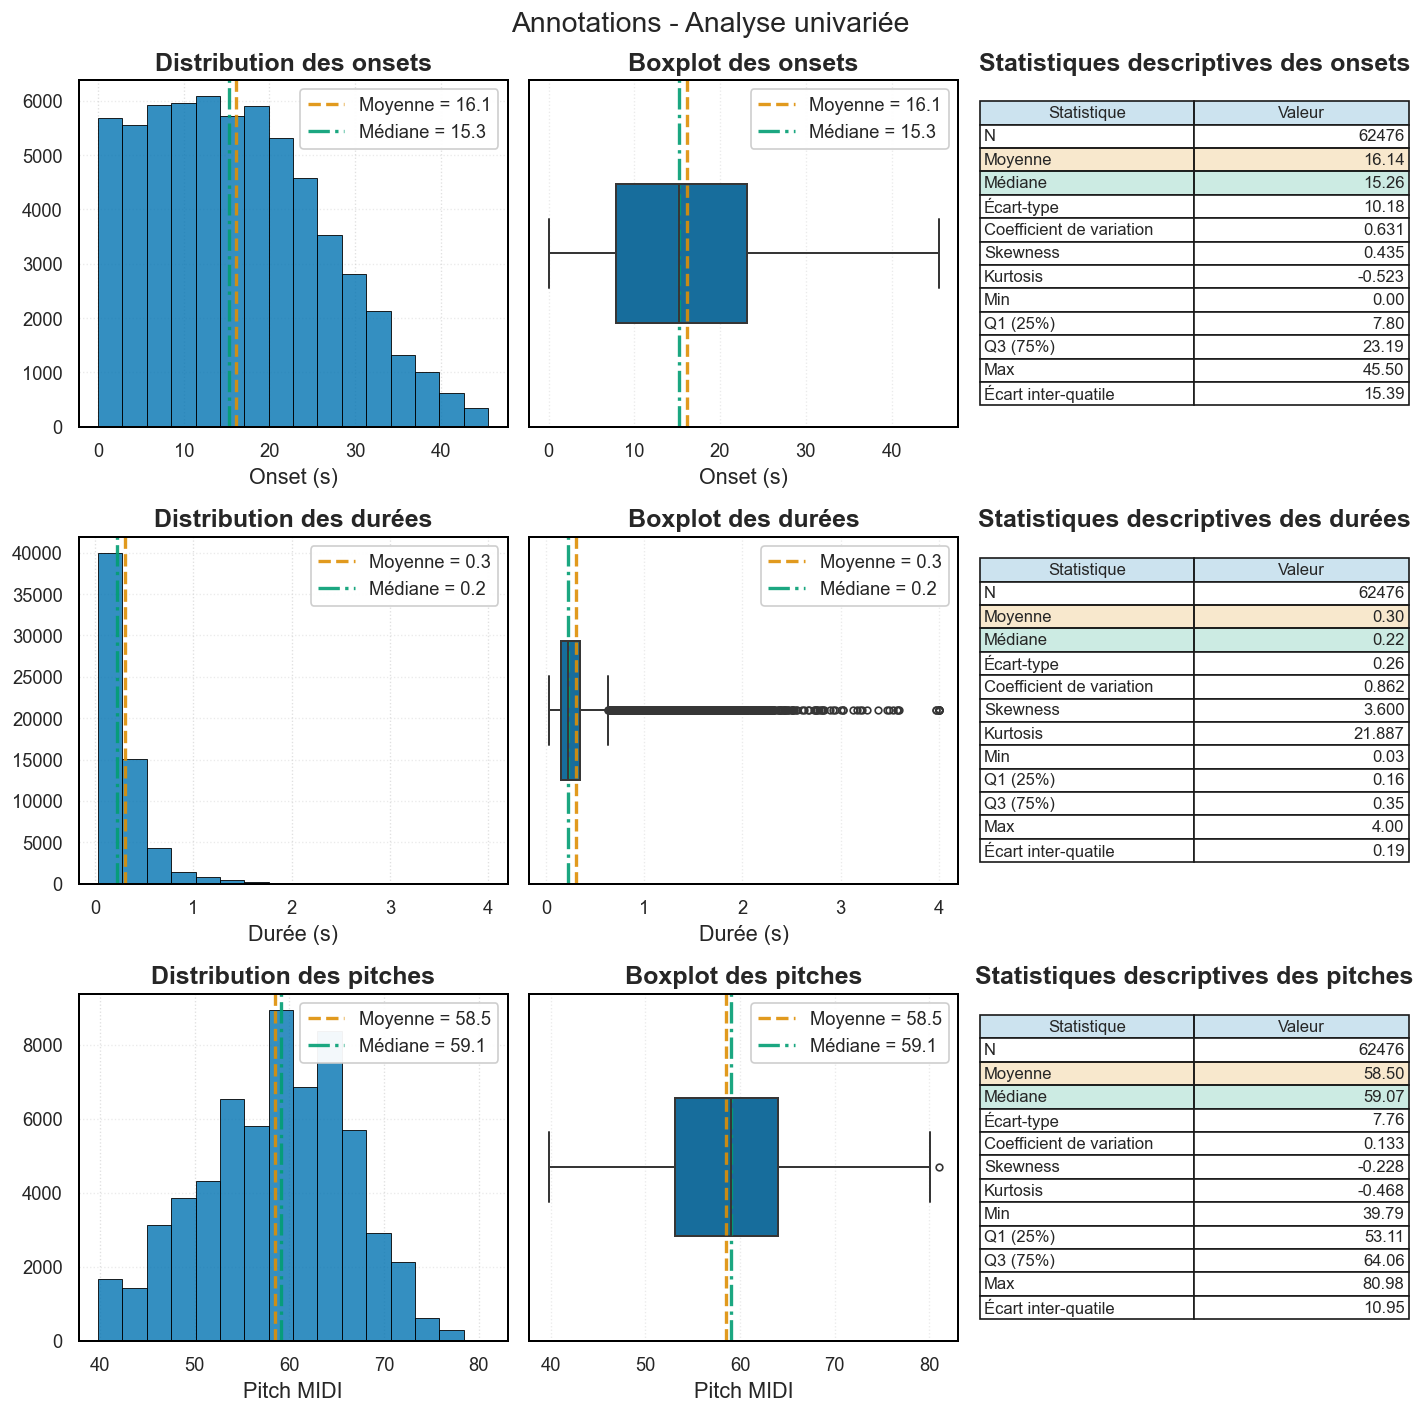

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

fig.suptitle("Annotations - Analyse univariée", fontsize=17)

# ===
# Distribution des onsets (time)
# ===
ax1 = axes[0, 0]
create_histplot(ax=ax1, df=df_annotation, column="time")
ax1.set_title("Distribution des onsets")
ax1.set_xlabel("Onset (s)")
ax1.set_ylabel(None)

ax2 = axes[0, 1]
create_boxplot(ax2, df_annotation, "time")
ax2.set_title("Boxplot des onsets")
ax2.set_xlabel("Onset (s)")

ax3 = axes[0, 2]
create_stats_panel(ax3, df_annotation, "time")
ax3.set_title("Statistiques descriptives des onsets")

# ===
# Distribution des durées
# ===
ax4 = axes[1, 0]
create_histplot(ax=ax4, df=df_annotation, column="duration")
ax4.set_title("Distribution des durées")
ax4.set_xlabel("Durée (s)")
ax4.set_ylabel(None)

ax5 = axes[1, 1]
create_boxplot(ax5, df_annotation, "duration")
ax5.set_title("Boxplot des durées")
ax5.set_xlabel("Durée (s)")

ax6 = axes[1, 2]
create_stats_panel(ax6, df_annotation, "duration")
ax6.set_title("Statistiques descriptives des durées")

# ===
# Distribution des pitch (value)
# ===
ax7 = axes[2, 0]
create_histplot(ax=ax7, df=df_annotation, column="value")
ax7.set_title("Distribution des pitches")
ax7.set_xlabel("Pitch MIDI")
ax7.set_ylabel(None)

ax8 = axes[2, 1]
create_boxplot(ax8, df_annotation, "value")
ax8.set_title("Boxplot des pitches")
ax8.set_xlabel("Pitch MIDI")

ax9 = axes[2, 2]
create_stats_panel(ax9, df_annotation, "value")
ax9.set_title("Statistiques descriptives des pitches")

plt.tight_layout()
plt.savefig(
    (FIGURES_DIRECTORY / "annotation_numerical_variables_distributions.png").as_posix()
)
plt.show()

Observations :
- Distribution des onsets (`time`) :
  - Le fait que la moyenne soit légérement supérieure à la médiane (16.14 > 15.26) et que le skewness soit strictement positif (0.435) indique une légère asymétrie positive. sur l'ensemble du dataset, le nombre de notes jouées décroit passé une vintaine de secondes, mais sans phénomène extrême.
  - L'écart interquartile est élevè $IQR=15.39$, montrant que les onsets sont largement répartis sur la durée des audios.
  - Le boxplot ne montre pas de valeurs abérantes avec la méthode de Turkey. Les onsets semblent cohérents.
- Distribution des durées (`duration`) :
  - La distribution des durées est fortement concentrée vers les petites valeurs. Au moins la moitiée des notes ont une durée inférieure ou égale à 0.22s. La distribution présente une longue queue jusqu'à 4 secondes.
  - La très forte skewness (3.6) montre une forte asymétrie positive, confirmant l'abondance de note courtes.
  - Le kurtosis très élevè (21.89) montre une distribution leptokurtique, confirmant la forte concentration des notes courtes.
  - Le boxplot montre de nombreux outliers avec la méthode de Turkey. Ces valeurs ne semblent cependant pas être des erreurs, elles correspondent probablement aux notes tenues ou à la raisonance de l'instrument.
  - Le coefficient de variabilité est élevé (0.86), indiquant une forte hétérogénéité des durées.
- Distribution des pitch (`value`) :
  - Les notes MIDI sont distribuées entre 40 et 81, ce qui correspond aux notes midi d'une guitare.
  - La proximité de la moyenne et de la médiane ainsi que la skewness légérement négative montre que la distribution est quasi symétrique.
  - Les quartiles $Q1=53$ et $Q3=64$ montre qu'au moins la moitié des notes se situe dans le registre médian de la guitare.
  - Le boxplot montre très peu de valeurs extrêmes.

Conclusions :
- Les onsets ne semblent pas préseter de biais.
- Les durées suivent une distribution fortement asymétrique contenant de nombreuses valeurs extrêmes plausibles. Si cette variable était utilisée comme feature, elle nécessiterait une normalisation, par exemple $x\mapsto \log(1+x)$.
- Les pitches semblent propres, homogènes et bien bornés. Ils contituent une bonne représentation du registre de la guitare.

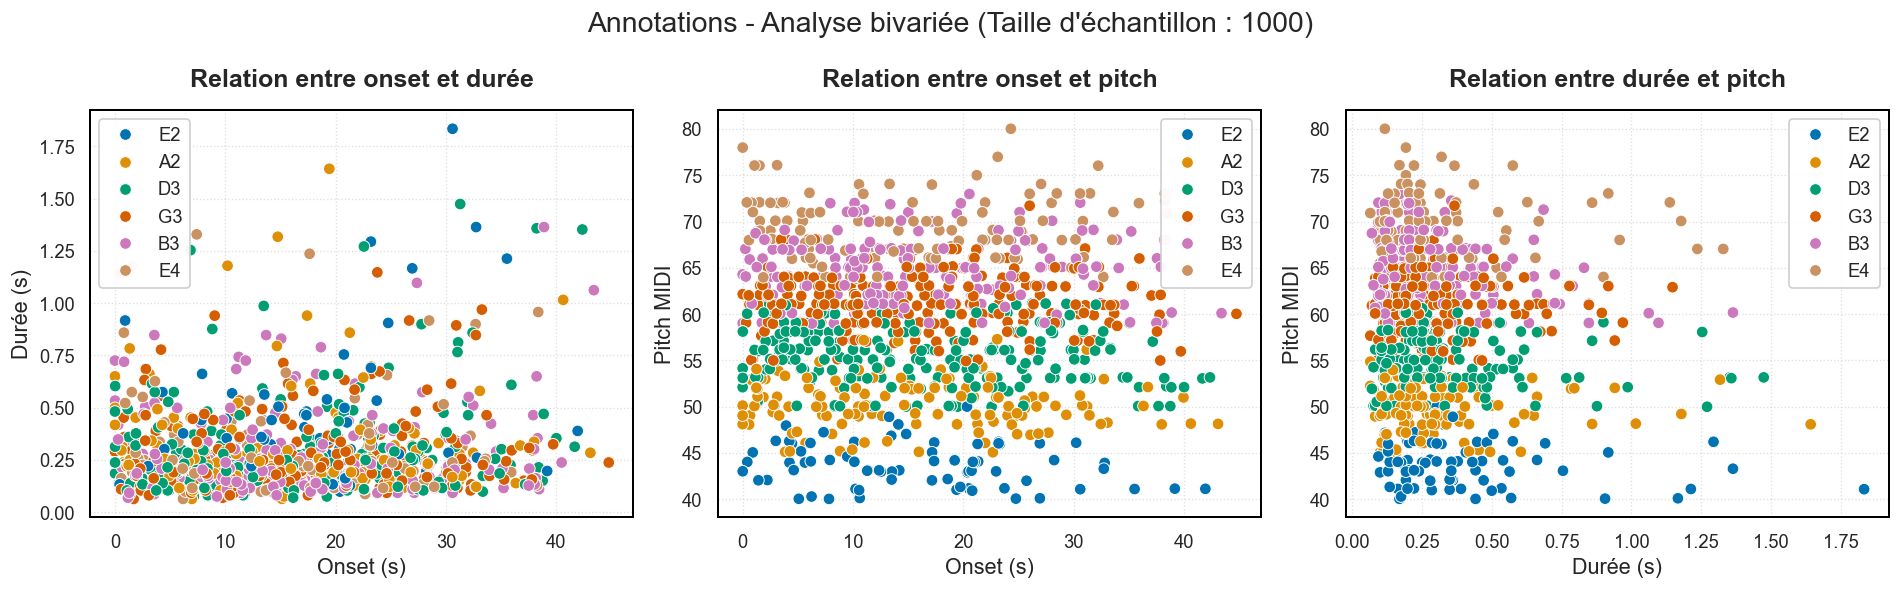

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

sample_size = 1000
df_annotation_sample = df_annotation.sample(sample_size, random_state=RANDOM_STATE)

fig.suptitle(
    f"Annotations - Analyse bivariée (Taille d'échantillon : {sample_size})",
    fontsize=17,
)

# ===
# Scatterplot time vs duration
# ===

sns.scatterplot(
    data=df_annotation_sample,
    x="time",
    y="duration",
    hue="string",
    hue_order=STRING_ORDER,
    palette=string_color,
    ax=ax1,
)
ax1.set_title("Relation entre onset et durée", pad=14)
ax1.set_xlabel("Onset (s)")
ax1.set_ylabel("Durée (s)")
ax1.legend()

# ===
# Scatterplot time vs value
# ===

sns.scatterplot(
    data=df_annotation_sample,
    x="time",
    y="value",
    hue="string",
    hue_order=STRING_ORDER,
    palette=string_color,
    ax=ax2,
)
ax2.set_title("Relation entre onset et pitch", pad=14)
ax2.set_xlabel("Onset (s)")
ax2.set_ylabel("Pitch MIDI")
ax2.legend()

# ===
# Scatterplot duration vs value
# ===

sns.scatterplot(
    data=df_annotation_sample,
    x="duration",
    y="value",
    hue="string",
    hue_order=STRING_ORDER,
    palette=string_color,
    ax=ax3,
)
ax3.set_title("Relation entre durée et pitch", pad=14)
ax3.set_xlabel("Durée (s)")
ax3.set_ylabel("Pitch MIDI")
ax3.legend()

plt.tight_layout()
plt.savefig(
    (FIGURES_DIRECTORY / "annotation_numerical_variables_scatterplot.png").as_posix()
)
plt.show()

Observations :
- Relation entre `onset` et `durée` : Aucun corrélation magnifeste.
- Relation entre `onset` et `pitch` : Aucun corrélation magnifeste.
- Relation entre `pitch` et `durée` : On retrouve le fait que les notes grave durent plus longtemps que les notes aigües, cependant cette corrélation ne semble pas forte.

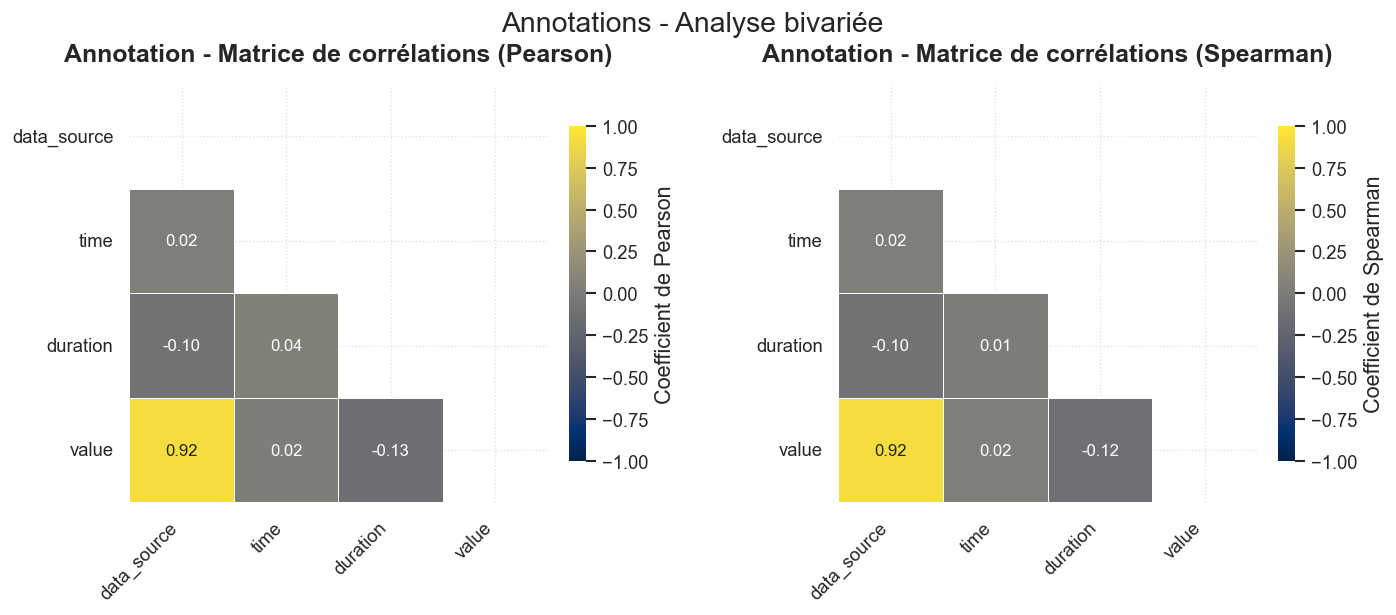

In [25]:
annotation_num_vars = ["data_source", "time", "duration", "value"]
annotation_corr_df_pearson = df_annotation[annotation_num_vars].corr(method="pearson")
annotation_corr_df_spearman = df_annotation[annotation_num_vars].corr(method="spearman")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Annotations - Analyse bivariée", fontsize=17)

# ===
# Pearson
# ===

heatmap = sns.heatmap(
    annotation_corr_df_pearson,
    mask=np.triu(np.ones_like(annotation_corr_df_pearson, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Pearson"},
    annot_kws={"size": 10},
    ax=ax1,
)
ax1.set_title("Annotation - Matrice de corrélations (Pearson)", pad=14)
ax1.set_xticks(
    np.arange(0.5, len(annotation_num_vars) + 0.5, 1),
    labels=annotation_num_vars,
    rotation=45,
    ha="right",
)
ax1.set_yticks(
    np.arange(0.5, len(annotation_num_vars) + 0.5, 1),
    labels=annotation_num_vars,
    rotation=0,
)

# ===
# Spearman
# ===

heatmap = sns.heatmap(
    annotation_corr_df_spearman,
    mask=np.triu(np.ones_like(annotation_corr_df_spearman, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Spearman"},
    annot_kws={"size": 10},
    ax=ax2,
)
ax2.set_title("Annotation - Matrice de corrélations (Spearman)", pad=14)
ax2.set_xticks(
    np.arange(0.5, len(annotation_num_vars) + 0.5, 1),
    labels=annotation_num_vars,
    rotation=45,
    ha="right",
)
ax2.set_yticks(
    np.arange(0.5, len(annotation_num_vars) + 0.5, 1),
    labels=annotation_num_vars,
    rotation=0,
)

plt.tight_layout()
plt.savefig(
    (FIGURES_DIRECTORY / "annotation_numerical_variables_correlations.png").as_posix()
)
plt.show()

Observation :
- Forte corrélation positive entre `value` et `data_source`.
- Faible corrélation négative entre `duration` et `data_source` et entre `duration` et `value`.

Hypothèse :
- La hauteur de la note jouée semble dépendre de la corde pincée. La corrélation n'est pas parfaite dû au chevauchement des notes.
- Bien que le coefficient de corrélation entre `duration` et `value` soit faible, on observe que plus la note est aigüe, moins elle dure.

### Analyse polyphonie

In [26]:
df_annotation["simultaneous_group"] = (
    df_annotation.sort_values(["title", "time"])
    .groupby("title")["time"]
    .diff()
    .gt(0.02)  # 20ms
    .cumsum()
)

polyphony = df_annotation.groupby(["title", "simultaneous_group"]).size()

polyphony.describe()

count    37346.000000
mean         1.672897
std          1.116175
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          6.000000
dtype: float64

En considérant que deux onsets ayant au plus 20ms d'écart sont deux notes jouées simultanées, on peut détecter les intervals et les accords et estimer la polyphonie du dataset. En moyenne, 1.67 notes sont jouées simultanément. Le troisième quartile nous indique que 25% des notes jouées font parties d'un interval ou d'un accord.

In [27]:
df_annotation["offset"] = df_annotation["time"] + df_annotation["duration"]

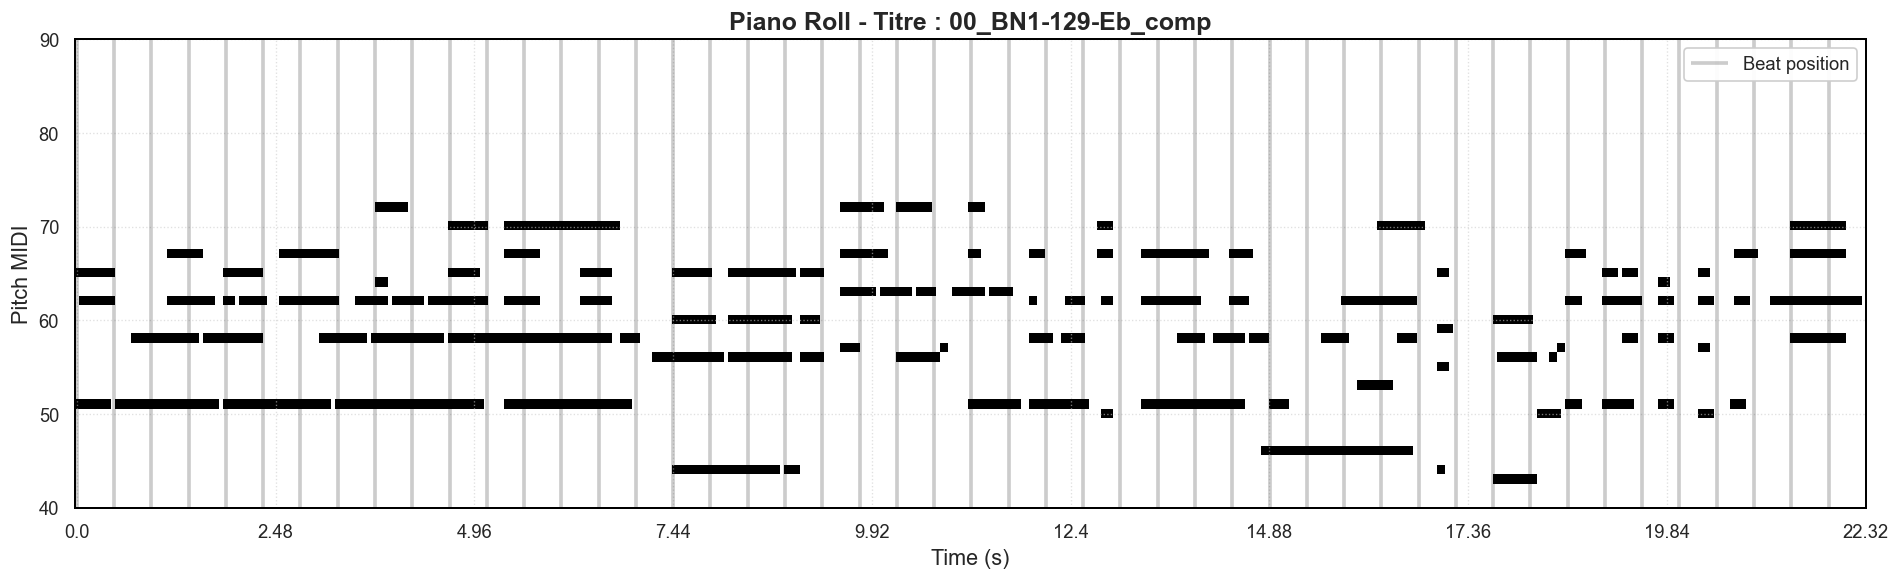

In [28]:
def create_piano_roll(annotations: pd.DataFrame, frames_per_seconde: int = 20):
    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(
        program=pretty_midi.instrument_name_to_program("Electric Guitar (clean)")
    )

    for _, row in annotations.iterrows():
        note = pretty_midi.Note(
            velocity=100,
            pitch=int(row["value"]),
            start=float(row["time"]),
            end=float(row["offset"]),
        )
        instrument.notes.append(note)

    pm.instruments.append(instrument)

    return pm.get_piano_roll(fs=frames_per_seconde)


title = "00_BN1-129-Eb_comp"
frames_per_seconde = 20

title_annotations = df_annotation[df_annotation["title"] == title]
title_metadata = df_metadata[df_metadata["title"] == title]

title_duration = title_metadata["duration"].values[0]
title_frames = frames_per_seconde * title_duration
title_tempo = title_metadata["tempo"].values[0]
piano_roll = create_piano_roll(title_annotations, frames_per_seconde=frames_per_seconde)

plt.figure(figsize=(16, 5))

beat_times = np.arange(0, title_duration, 60 / title_tempo)
plt.vlines(
    beat_times * frames_per_seconde,
    ymin=0,
    ymax=128,
    alpha=0.2,
    colors="black",
    label="Beat position",
)

plt.imshow(
    piano_roll,
    cmap="binary",
    aspect="auto",
    origin="lower",
)
plt.ylabel("Pitch MIDI")
plt.ylim((40, 90))
plt.xlabel("Time (s)")
plt.xticks(
    ticks=np.linspace(0, title_frames, 10),
    labels=np.round(np.linspace(0, title_duration, 10), 2),
)
plt.title(f"Piano Roll - Titre : {title}")
plt.legend()

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "piano_roll.png").as_posix())
plt.show()

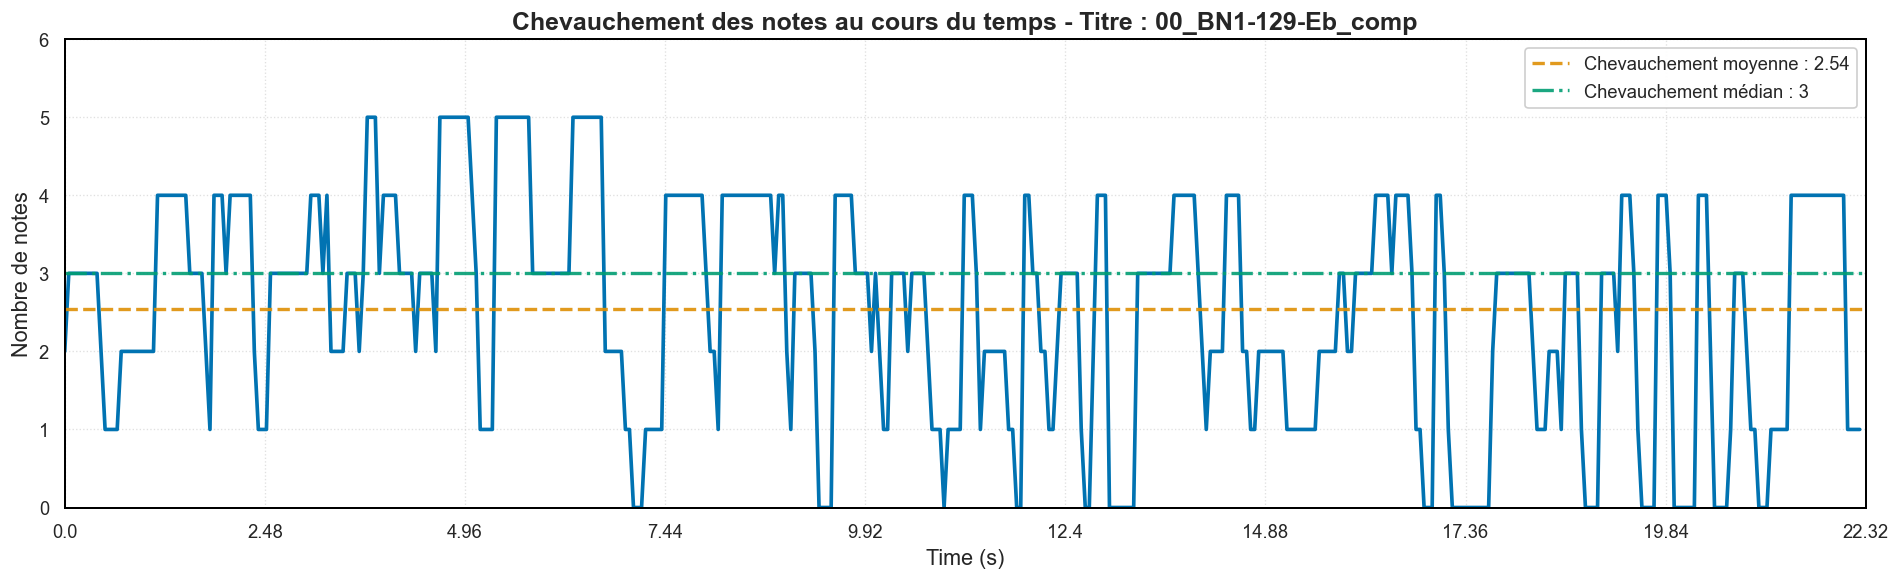

In [29]:
plt.figure(figsize=(16, 5))

overlapping_piano_roll = (piano_roll > 0).sum(axis=0)
plt.plot(overlapping_piano_roll)

overlapping_piano_roll_mean = overlapping_piano_roll.mean()
plt.axhline(
    y=overlapping_piano_roll_mean,
    color=COLORBLIND_PALETTE[1],
    linestyle="--",
    linewidth=2,
    alpha=0.9,
    label=f"Chevauchement moyenne : {overlapping_piano_roll_mean:.2f}",
)

overlapping_piano_roll_median = np.median(overlapping_piano_roll)
plt.axhline(
    y=overlapping_piano_roll_median,
    color=COLORBLIND_PALETTE[2],
    linestyle="-.",
    linewidth=2,
    alpha=0.9,
    label=f"Chevauchement médian : {overlapping_piano_roll_median:.0f}",
)

plt.ylabel("Nombre de notes")
plt.ylim((0, 6))
plt.xlabel("Time (s)")
plt.xticks(
    ticks=np.linspace(0, title_frames, 10),
    labels=np.round(np.linspace(0, title_duration, 10), 2),
)
plt.xlim((0, title_frames))
plt.title(f"Chevauchement des notes au cours du temps - Titre : {title}")
plt.legend()

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "overlapping.png").as_posix())
plt.show()

Observations :
- Le chevauchement des notes est important.

## Audio (MinIO)

In [30]:
audio_hex_pickup_debleeded_objects = [
    obj
    for obj in minio.list_raw(prefix="GuitarSet/")
    if "audio_hex-pickup_debleeded.wav" in obj.object_name
]

audio_hex_pickup_original_objects = [
    obj
    for obj in minio.list_raw(prefix="GuitarSet/")
    if "audio_hex-pickup_original.wav" in obj.object_name
]

audio_mono_mic_objects = [
    obj
    for obj in minio.list_raw(prefix="GuitarSet/")
    if "audio_mono-mic.wav" in obj.object_name
]

audio_mono_pickup_mix_objects = [
    obj
    for obj in minio.list_raw(prefix="GuitarSet/")
    if "audio_mono-pickup_mix.wav" in obj.object_name
]

print("Audio type : audio_mono-pickup_debleeded")
print("  Nombre d'audio    :", len(audio_hex_pickup_debleeded_objects))
print(
    "  Taille total (Mo) :",
    sum(obj.size for obj in audio_hex_pickup_debleeded_objects) // (1024**2),
)
print()

print("Audio type : audio_hex-pickup_original")
print("  Nombre d'audio    :", len(audio_hex_pickup_original_objects))
print(
    "  Taille total (Mo) :",
    sum(obj.size for obj in audio_hex_pickup_original_objects) // (1024**2),
)
print()

print("Audio type : audio_mono-mic")
print("  Nombre d'audio    :", len(audio_mono_mic_objects))
print(
    "  Taille total (Mo) :",
    sum(obj.size for obj in audio_mono_mic_objects) // (1024**2),
)
print()

print("Audio type : audio_mono-pickup_mix")
print("  Nombre d'audio    :", len(audio_mono_pickup_mix_objects))
print(
    "  Taille total (Mo) :",
    sum(obj.size for obj in audio_mono_pickup_mix_objects) // (1024**2),
)
print()

Audio type : audio_mono-pickup_debleeded
  Nombre d'audio    : 360
  Taille total (Mo) : 5535

Audio type : audio_hex-pickup_original
  Nombre d'audio    : 360
  Taille total (Mo) : 5535

Audio type : audio_mono-mic
  Nombre d'audio    : 360
  Taille total (Mo) : 922

Audio type : audio_mono-pickup_mix
  Nombre d'audio    : 360
  Taille total (Mo) : 922



### Etude d'un audio

#### Analyse du signal

In [31]:
title = "00_BN1-129-Eb_comp"
audio_data, sample_rate = minio.get_audio(
    bucket_name=MINIO_SETTINGS.bucket_raw,
    file_name=f"GuitarSet/{title}/audio_mono-pickup_mix.wav",
)

print(f"Nombre de canaux : {len(audio_data.shape)}")

Nombre de canaux : 1


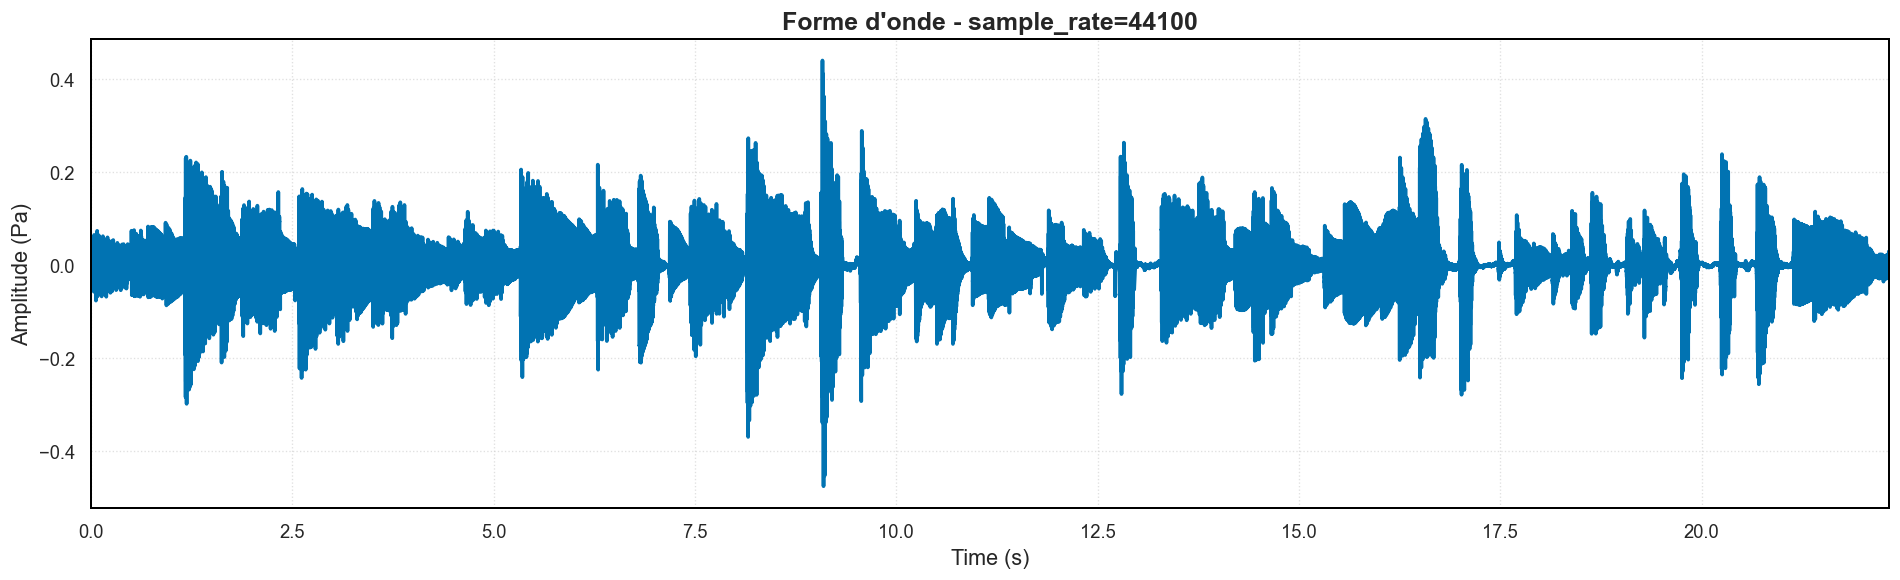

In [32]:
duration_audio = len(audio_data) / sample_rate
time_audio = np.linspace(0, title_duration, len(audio_data))

plt.figure(figsize=(16, 5))

plt.plot(time_audio, audio_data)
plt.title(f"Forme d'onde - sample_rate={sample_rate}")
plt.xlabel("Time (s)")
plt.xlim((0, duration_audio))
plt.ylabel("Amplitude (Pa)")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "waveform.png").as_posix())
plt.show()

In [33]:
print("Durée :                    ", duration_audio)
print("Taille d'échantillonage :  ", sample_rate)
print("Amplitude moyenne :        ", np.mean(audio_data))
print("Ecart-type de l'amplitude :", np.std(audio_data))
print("Amplitude maximale :       ", np.max(audio_data))

Durée :                     22.32439909297052
Taille d'échantillonage :   44100
Amplitude moyenne :         -0.0001437703636590648
Ecart-type de l'amplitude : 0.05107147673171689
Amplitude maximale :        0.439300537109375


#### Analyse fréquentielle

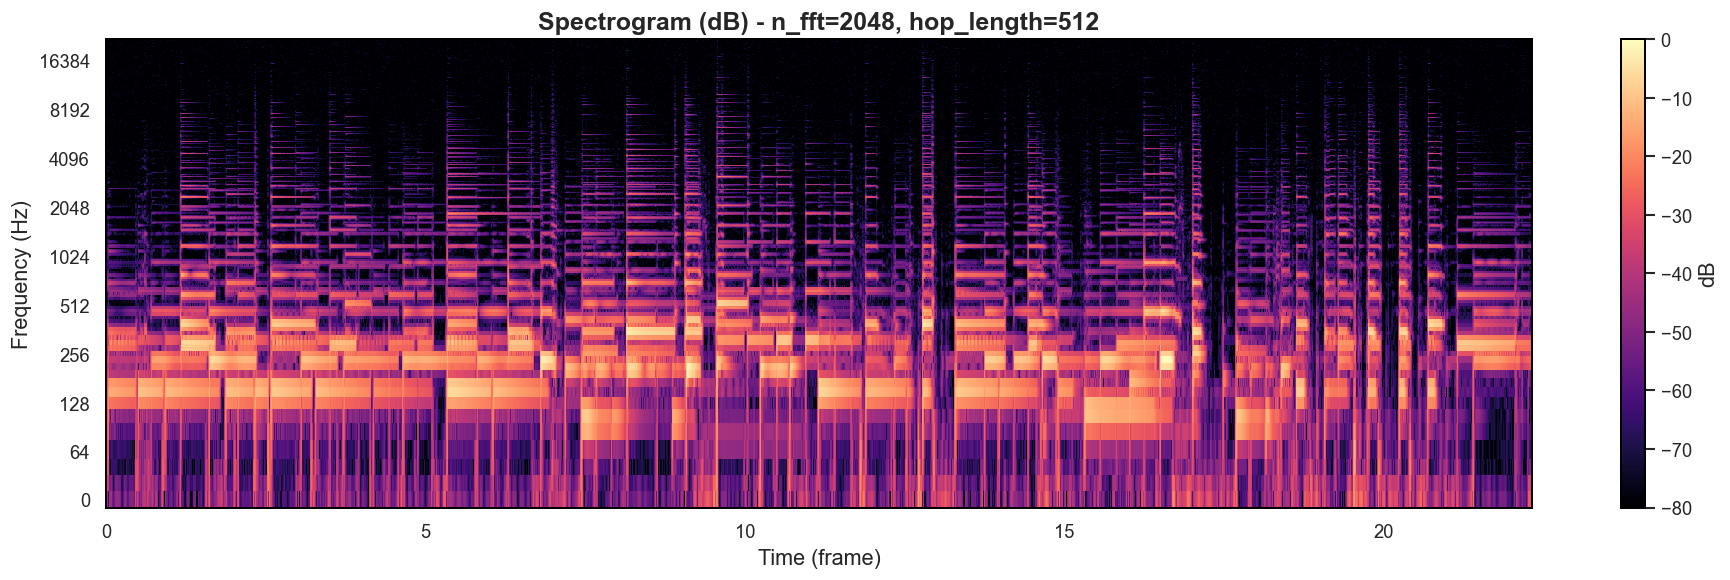

In [34]:
N_FFT = 2048
HOP_LENGTH = 512

short_term_fourier_transform_coefficients = librosa.stft(
    audio_data, n_fft=N_FFT, hop_length=HOP_LENGTH
)
short_term_fourier_transform_coefficients_db = librosa.amplitude_to_db(
    np.abs(short_term_fourier_transform_coefficients), ref=np.max
)

plt.figure(figsize=(16, 5))

librosa.display.specshow(
    short_term_fourier_transform_coefficients_db,
    sr=sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="log",
)
plt.title(f"Spectrogram (dB) - n_fft={N_FFT}, hop_length={HOP_LENGTH}")
plt.xlabel("Time (frame)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="dB")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "spectrogram.png").as_posix())
plt.show()

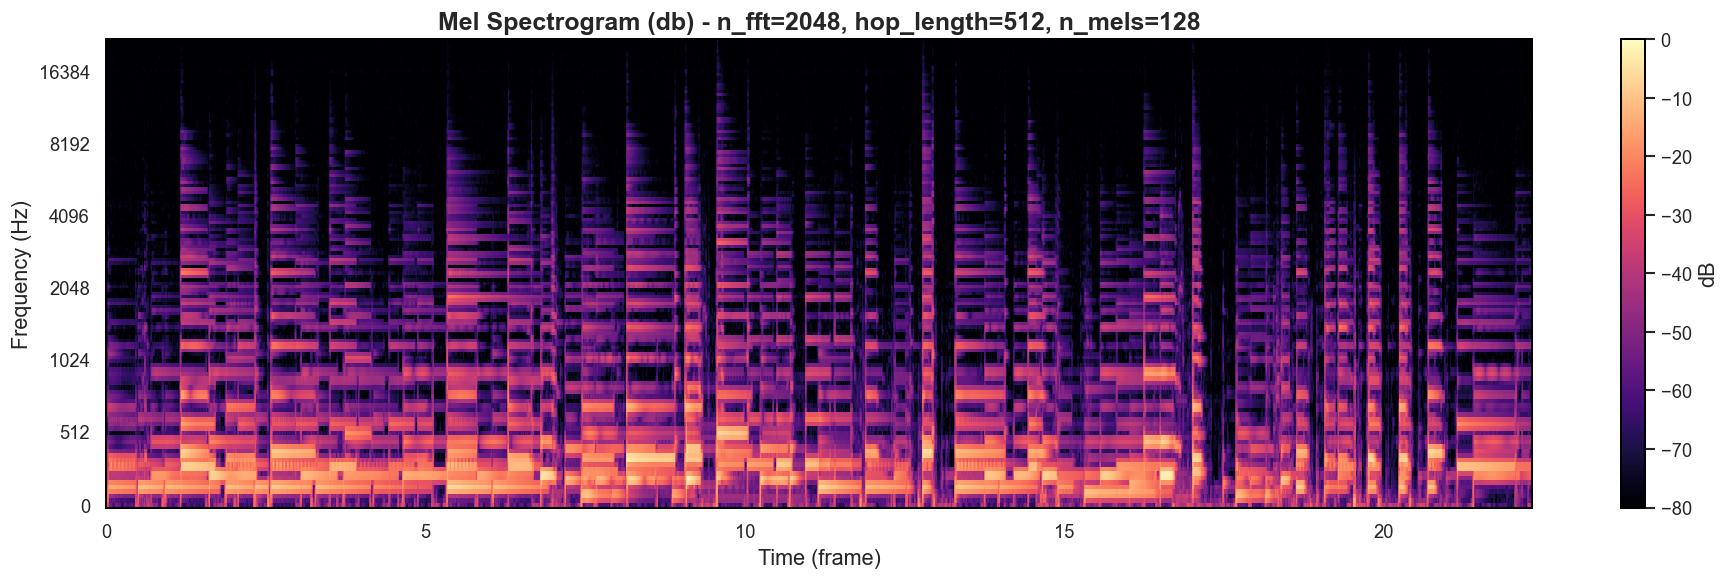

In [35]:
N_MELS = 128

mel_spectrogram = librosa.feature.melspectrogram(
    y=audio_data,
    sr=sample_rate,
    n_mels=N_MELS,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    fmin=0,
    fmax=sample_rate / 2,
    power=2,
)
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

plt.figure(figsize=(16, 5))

librosa.display.specshow(
    mel_spectrogram_db, sr=sample_rate, x_axis="time", y_axis="mel"
)
plt.title(
    f"Mel Spectrogram (db) - n_fft={N_FFT}, hop_length={HOP_LENGTH}, n_mels={N_MELS}"
)
plt.xlabel("Time (frame)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="dB")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "mel_spectrogram.png").as_posix())
plt.show()

#### Analyse musicale

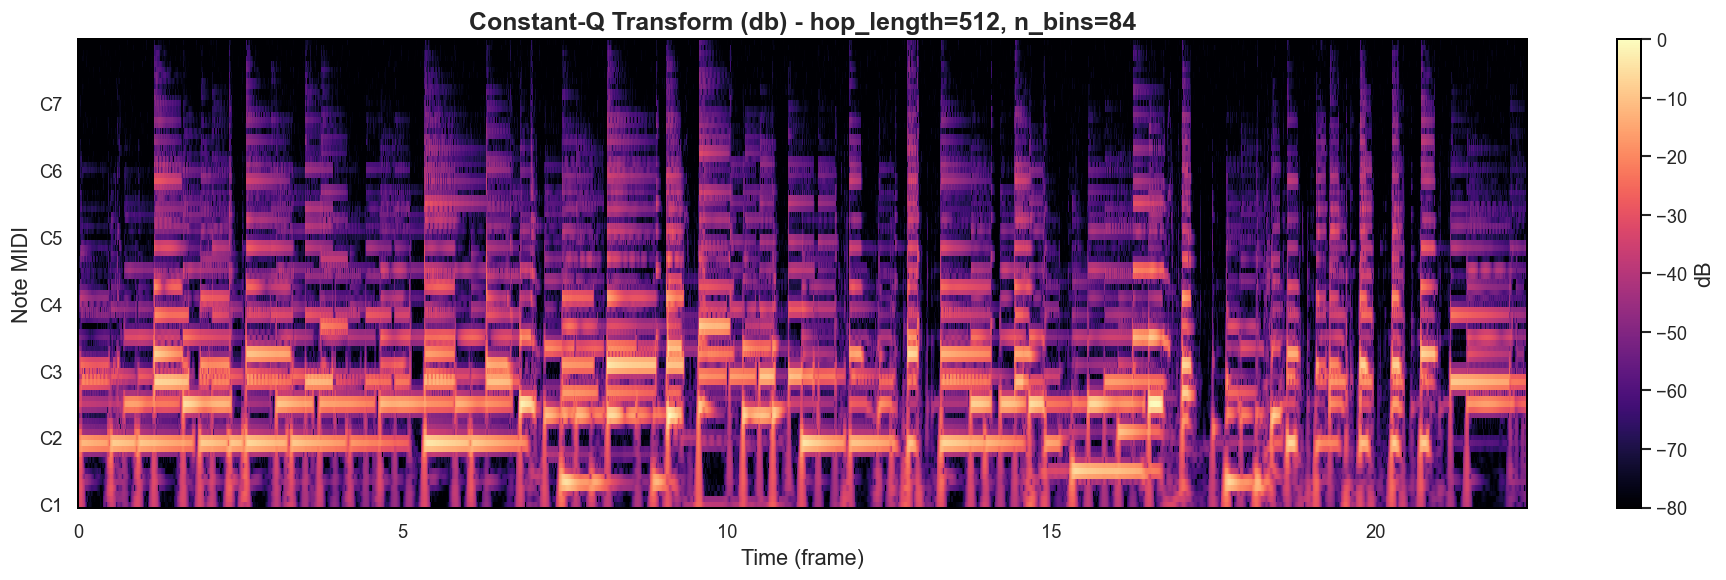

In [36]:
N_BINS = 84

cqt = librosa.cqt(
    audio_data,
    sr=sample_rate,
    hop_length=HOP_LENGTH,
    n_bins=N_BINS,
    fmin=librosa.note_to_hz("E2"),
    bins_per_octave=12,
)
cqt_db = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)

plt.figure(figsize=(16, 5))

librosa.display.specshow(cqt_db, sr=sample_rate, x_axis="time", y_axis="cqt_note")
plt.title(f"Constant-Q Transform (db) - hop_length={HOP_LENGTH}, n_bins={N_BINS}")
plt.xlabel("Time (frame)")
plt.ylabel("Note MIDI")
plt.colorbar(label="dB")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "cqt.png").as_posix())
plt.show()

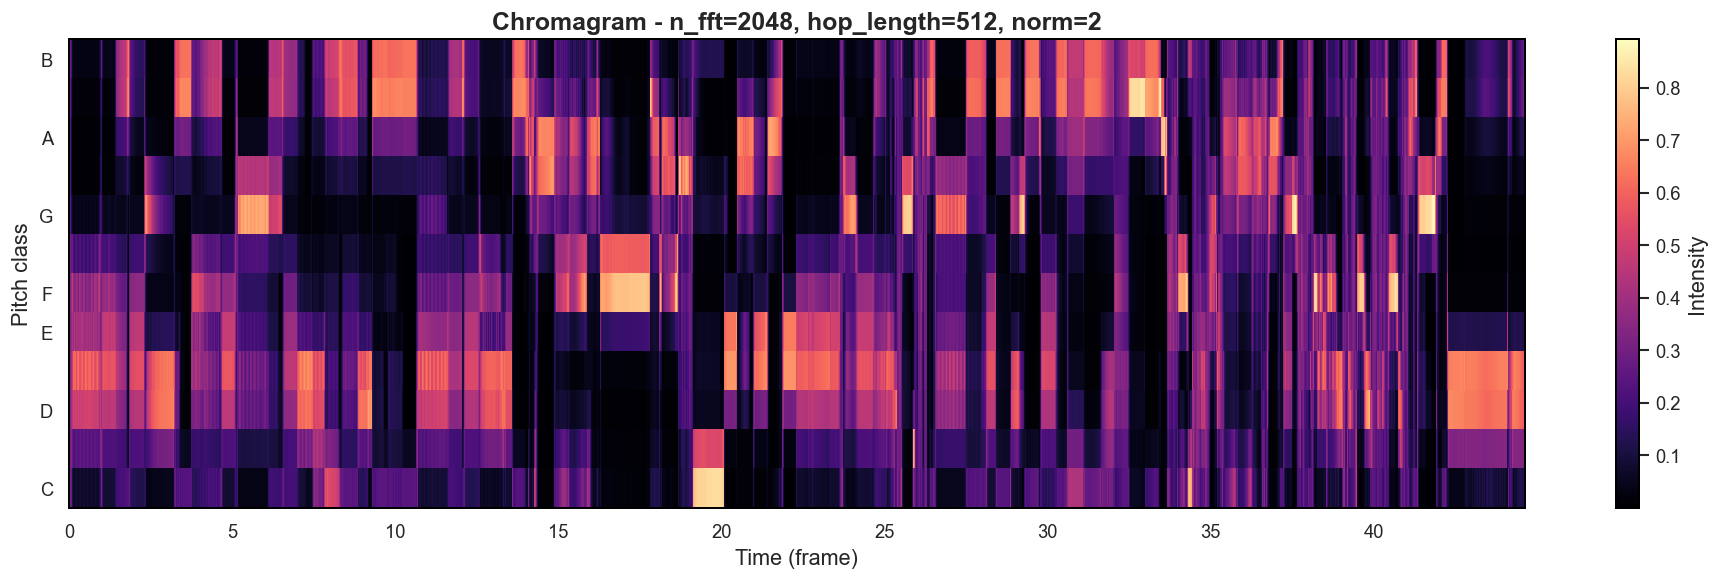

In [37]:
NORM = 2

chroma = librosa.feature.chroma_stft(
    y=audio_data,
    sr=sample_rate,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    norm=NORM,
    tuning=None,
)

plt.figure(figsize=(16, 5))

librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
plt.title(f"Chromagram - n_fft={N_FFT}, hop_length={HOP_LENGTH}, norm={NORM}")
plt.xlabel("Time (frame)")
plt.ylabel("Pitch class")
plt.colorbar(label="Intensity")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "chromagram.png").as_posix())
plt.show()

#### Features ML

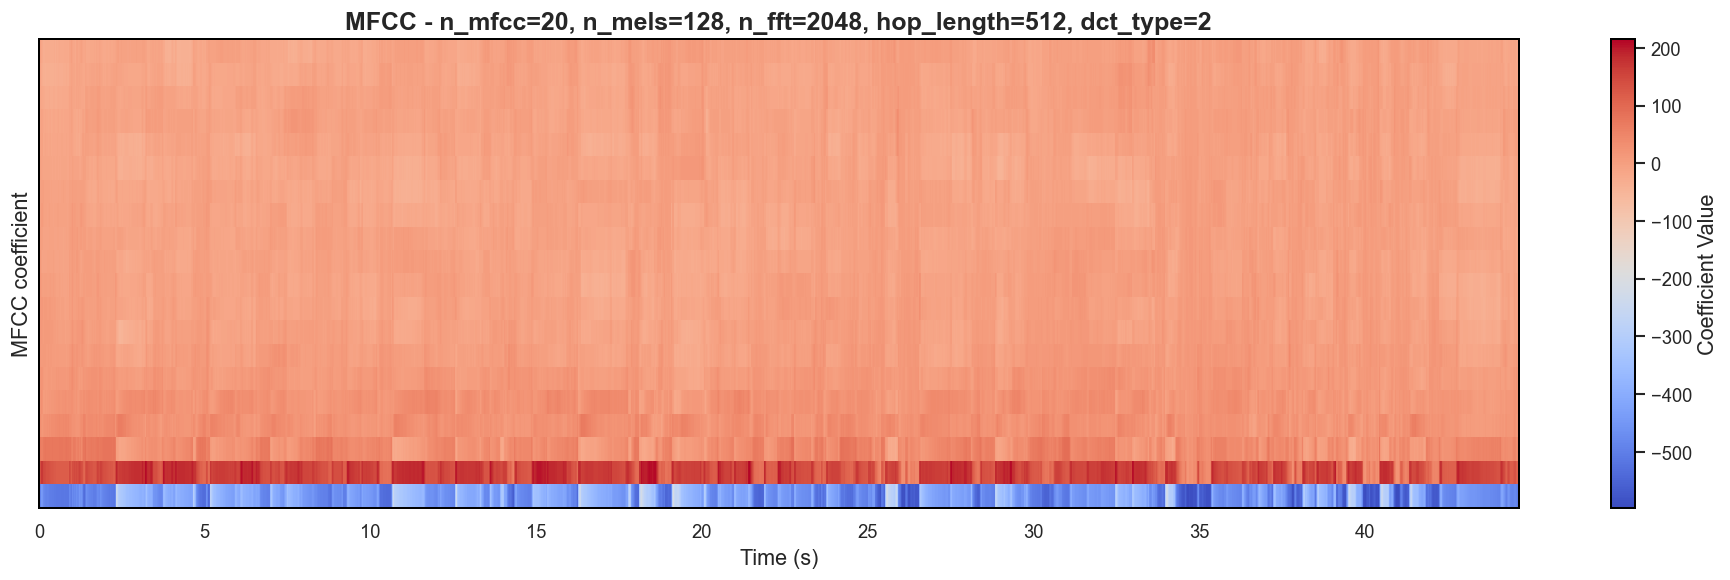

In [38]:
N_MFCC = 20
DCT_TYPE = 2

mfcc = librosa.feature.mfcc(
    y=audio_data,
    sr=sample_rate,
    n_mfcc=N_MFCC,
    n_mels=N_MELS,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    fmin=0,
    fmax=sample_rate / 2,
    norm="ortho",
    dct_type=DCT_TYPE,
)

plt.figure(figsize=(16, 5))

librosa.display.specshow(mfcc, x_axis="time")
plt.title(
    f"MFCC - n_mfcc={N_MFCC}, n_mels={N_MELS}, n_fft={N_FFT}, hop_length={HOP_LENGTH}, dct_type={DCT_TYPE}"
)
plt.xlabel("Time (s)")
plt.ylabel("MFCC coefficient")
plt.colorbar(label="Coefficient Value")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "mfcc.png").as_posix())
plt.show()

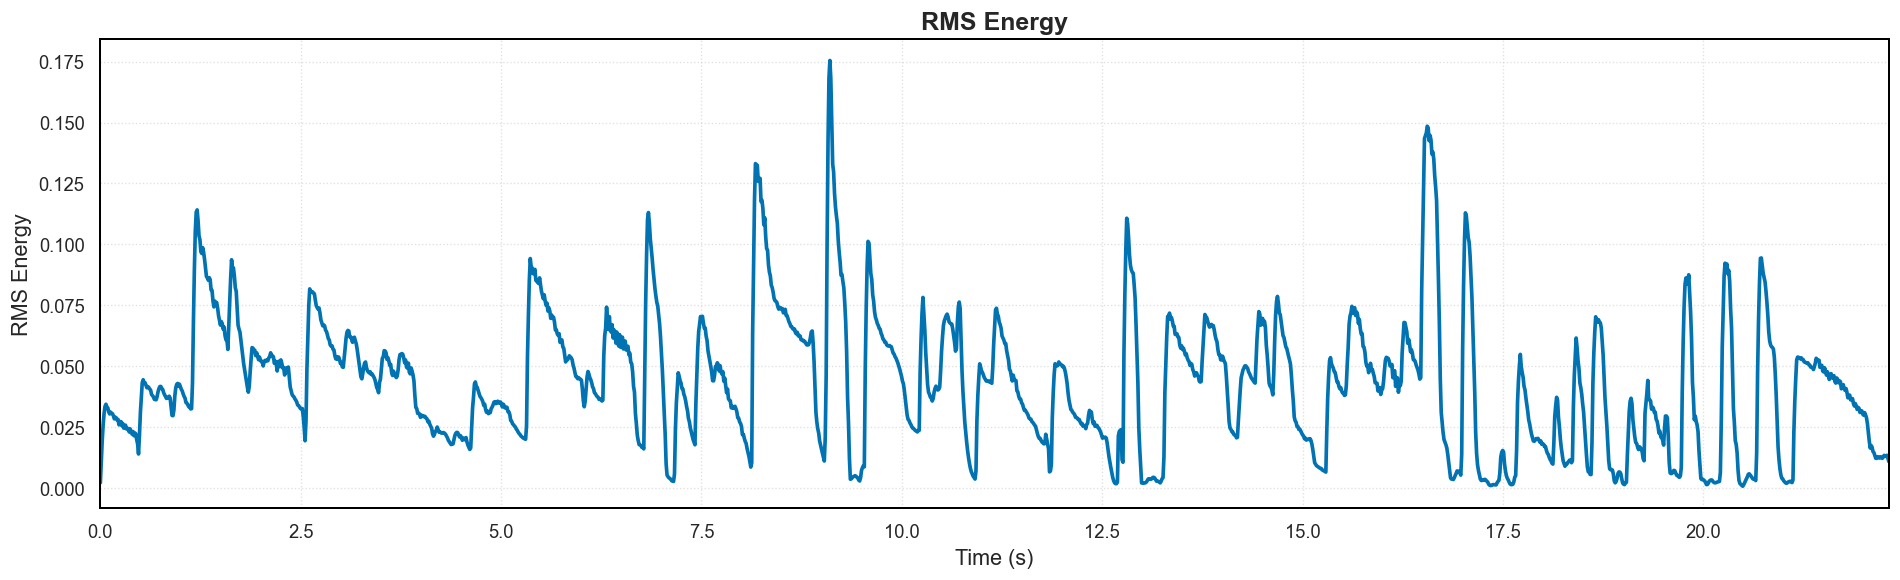

In [39]:
rms = librosa.feature.rms(y=audio_data, frame_length=N_FFT, hop_length=HOP_LENGTH)

times = librosa.frames_to_time(np.arange(len(rms[0])), sr=sample_rate, hop_length=512)

plt.figure(figsize=(16, 5))

plt.plot(times, rms[0])
plt.xlim(0, times.max())

plt.title("RMS Energy")
plt.xlabel("Time (s)")
plt.ylabel("RMS Energy")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "rms.png").as_posix())
plt.show()

Observations :
- Pics réguliers et décroissance exponentielle typique de la guitare.

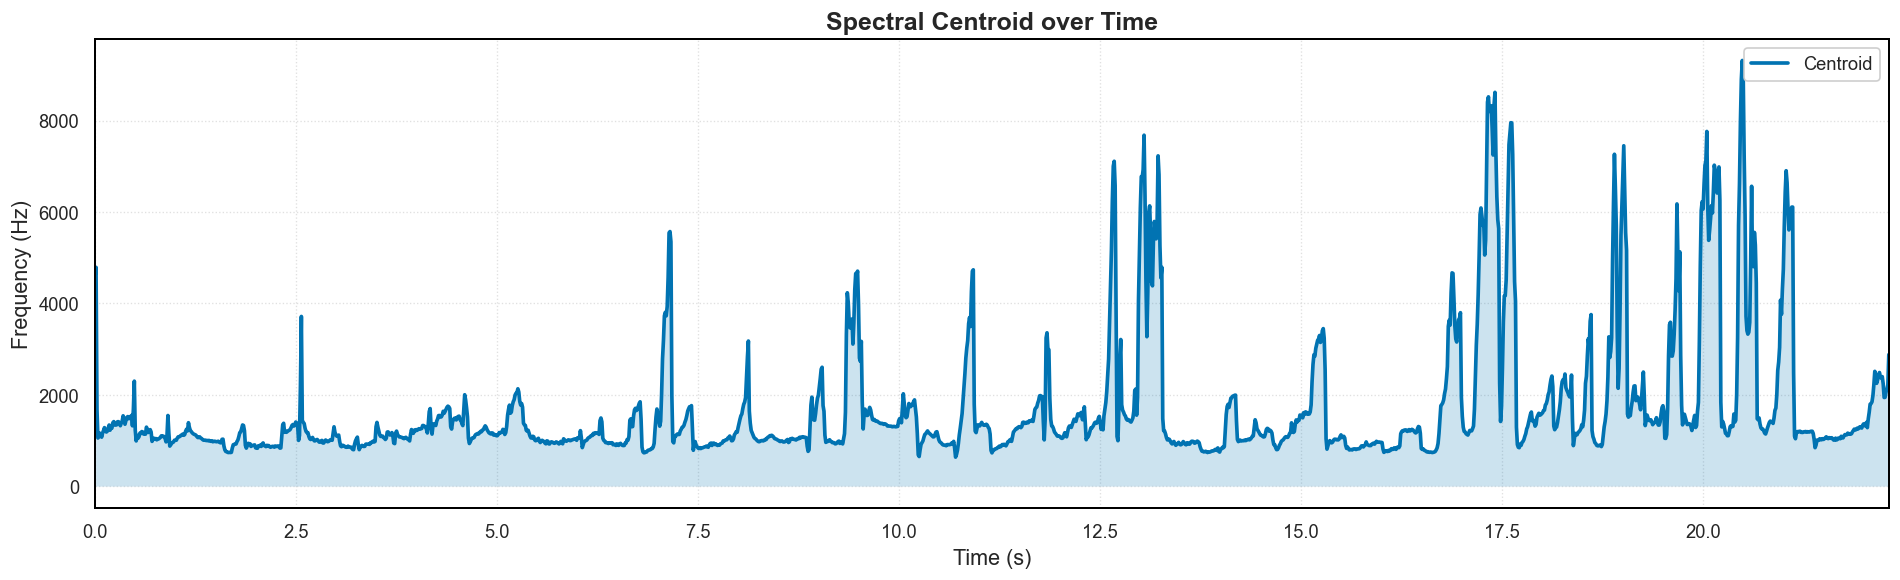

In [40]:
centroid = librosa.feature.spectral_centroid(
    y=audio_data, sr=sample_rate, n_fft=N_FFT, hop_length=HOP_LENGTH, center=True
)

times = librosa.frames_to_time(
    np.arange(len(centroid[0])), sr=sample_rate, hop_length=512
)

plt.figure(figsize=(16, 5))

plt.plot(times, centroid[0], label="Centroid")
plt.fill_between(times, centroid[0], alpha=0.2)
plt.xlim(0, times.max())

plt.title("Spectral Centroid over Time")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.legend()

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "spectral_centroid.png").as_posix())
plt.show()

Observation :
- Centroid très variable indiquant un signal riche.

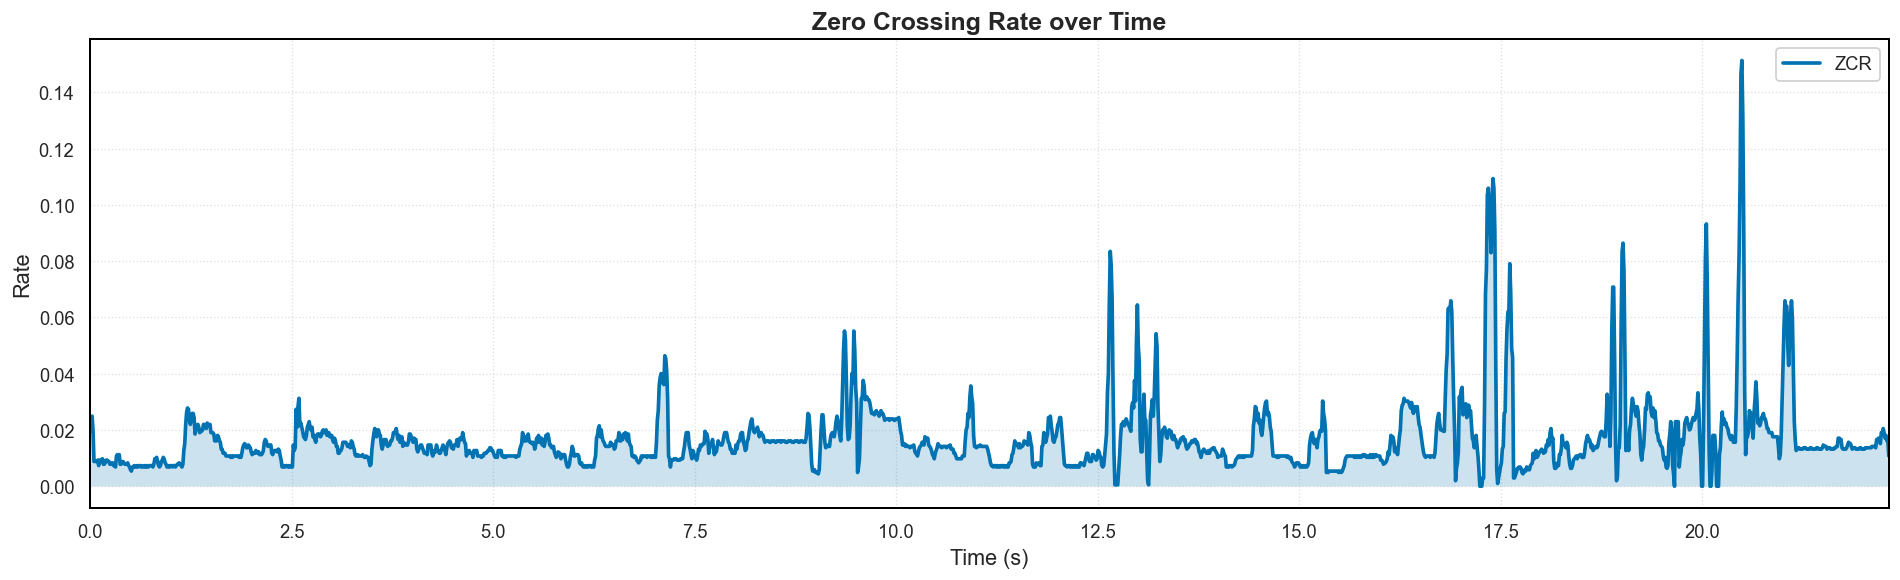

In [41]:
zcr = librosa.feature.zero_crossing_rate(
    audio_data, frame_length=N_FFT, hop_length=HOP_LENGTH, center=True
)

times = librosa.frames_to_time(np.arange(len(zcr[0])), sr=sample_rate, hop_length=512)

plt.figure(figsize=(16, 5))

plt.plot(times, zcr[0], label="ZCR")
plt.fill_between(times, zcr[0], alpha=0.2)
plt.xlim(0, times.max())

plt.title("Zero Crossing Rate over Time")
plt.xlabel("Time (s)")
plt.ylabel("Rate")
plt.legend()

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "zero_crossing_rate.png").as_posix())
plt.show()

Observation :
- ZCR faible : signal dominé par les basses fréquences.

#### Analyse rythmique

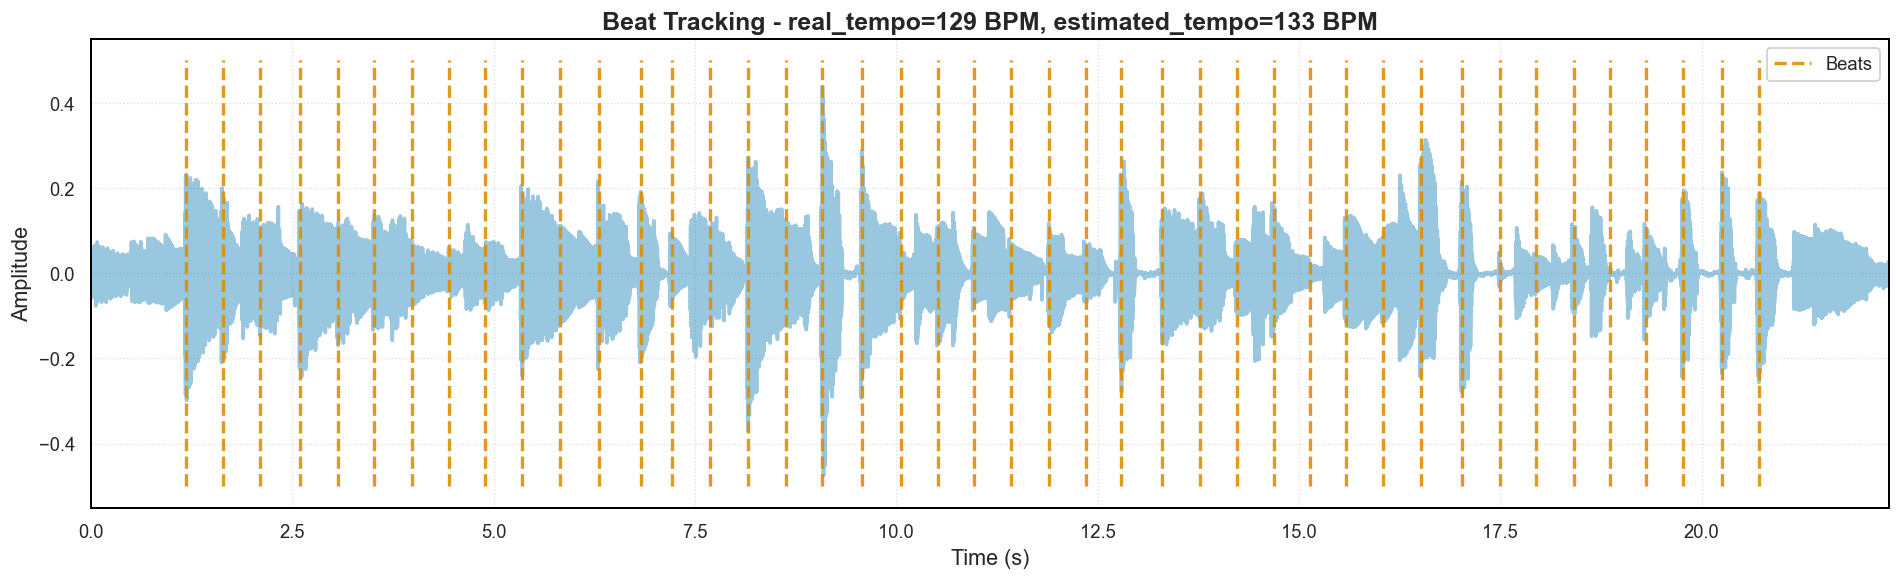

In [43]:
estimated_tempo, beats = librosa.beat.beat_track(
    y=audio_data, sr=sample_rate, hop_length=HOP_LENGTH
)

beat_times = librosa.frames_to_time(beats, sr=sample_rate, hop_length=HOP_LENGTH)

plt.figure(figsize=(16, 5))

times = np.arange(len(audio_data)) / sample_rate
plt.plot(times, audio_data, alpha=0.4)
plt.xlim(0, times.max())

plt.vlines(
    beat_times,
    -0.5,
    0.5,
    colors=COLORBLIND_PALETTE[1],
    linestyles="--",
    linewidth=2,
    alpha=0.9,
    label="Beats",
)

plt.title(
    f"Beat Tracking - real_tempo={title_tempo:.0f} BPM, estimated_tempo={estimated_tempo[0]:.0f} BPM"
)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "beat_tracking.png").as_posix())
plt.show()

Observation :
- tempo globalement régulier, peu de variation.

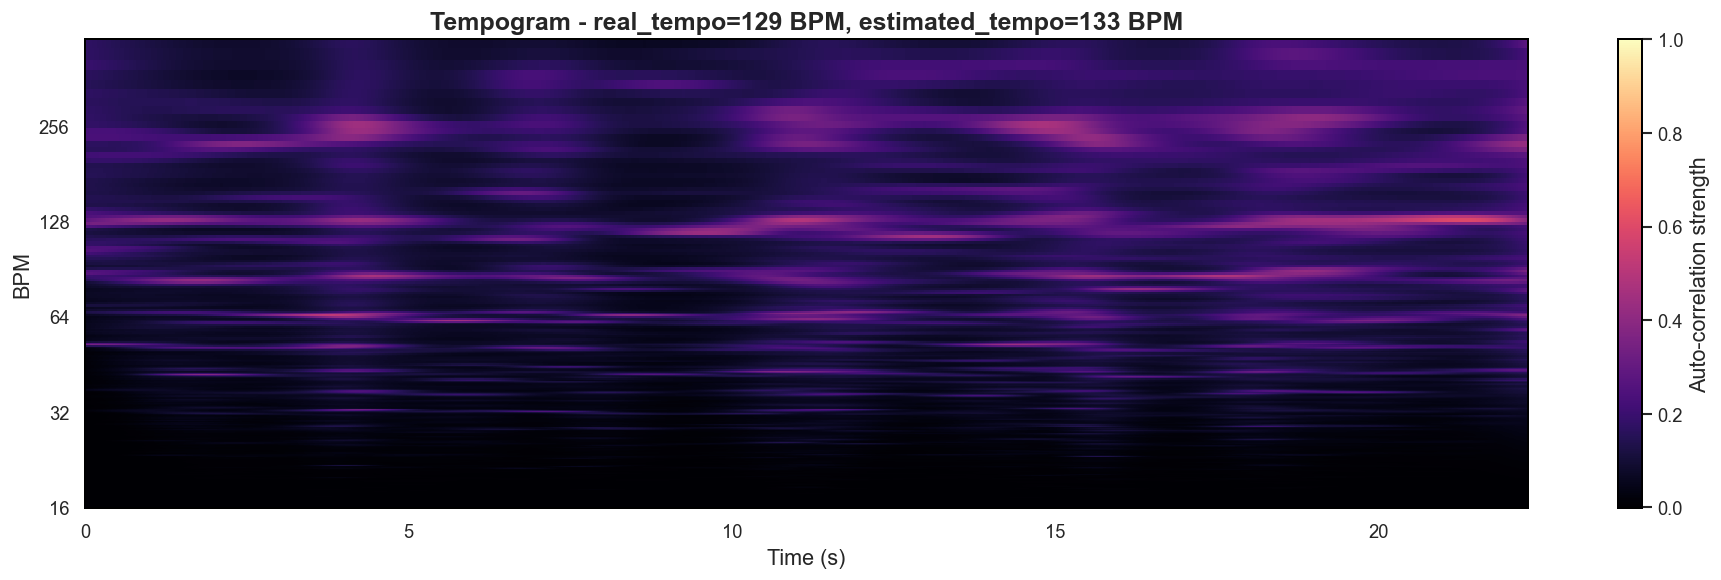

In [44]:
estimated_tempo, beats = librosa.beat.beat_track(
    y=audio_data, sr=sample_rate, hop_length=HOP_LENGTH
)

tempogram = librosa.feature.tempogram(
    y=audio_data, sr=sample_rate, hop_length=HOP_LENGTH
)

plt.figure(figsize=(16, 5))

librosa.display.specshow(
    tempogram, sr=sample_rate, hop_length=HOP_LENGTH, x_axis="time", y_axis="tempo"
)

plt.title(
    f"Tempogram - real_tempo={title_tempo:.0f} BPM, estimated_tempo={estimated_tempo[0]:.0f} BPM"
)
plt.colorbar(label="Auto-correlation strength")
plt.xlabel("Time (s)")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "tempogram.png").as_posix())
plt.show()

Observation :
- Confirmation de la faible variation du tempo.

#### Analyse de la qualité du signal

In [45]:
def indices_to_segments(indices, sr):
    if len(indices) == 0:
        return []

    splits = np.where(np.diff(indices) > 1)[0] + 1
    groups = np.split(indices, splits)

    return [(g[0] / sr, g[-1] / sr) for g in groups]


silence = np.where(np.abs(audio_data) < 1e-4)[0]
silence_ratio = len(silence) / len(audio_data) * 100
print(f"Pourcentage de silence    : {silence_ratio:.2f}%")

silence_segments = indices_to_segments(silence, sample_rate)
print(f"Nombre de segment silence : {len(silence_segments)}")

silence_times = silence / sample_rate

Pourcentage de silence    : 0.52%
Nombre de segment silence : 4286


In [46]:
clipping = np.where(np.abs(audio_data) >= 0.99)[0]
clipping_ratio = len(clipping) / len(audio_data) * 100
print(f"Pourcentage de clipping    : {clipping_ratio:.2f}%")

if clipping_ratio > 10:
    print("-> Signal fortement dégradé")
elif clipping_ratio > 1:
    print("-> Signal saturé")
else:
    print("-> Signal propre")


clipping_segments = indices_to_segments(clipping, sample_rate)
print(f"Nombre de segment clipping : {len(clipping_segments)}")

clipping_times = clipping / sample_rate

Pourcentage de clipping    : 0.00%
-> Signal propre
Nombre de segment clipping : 0


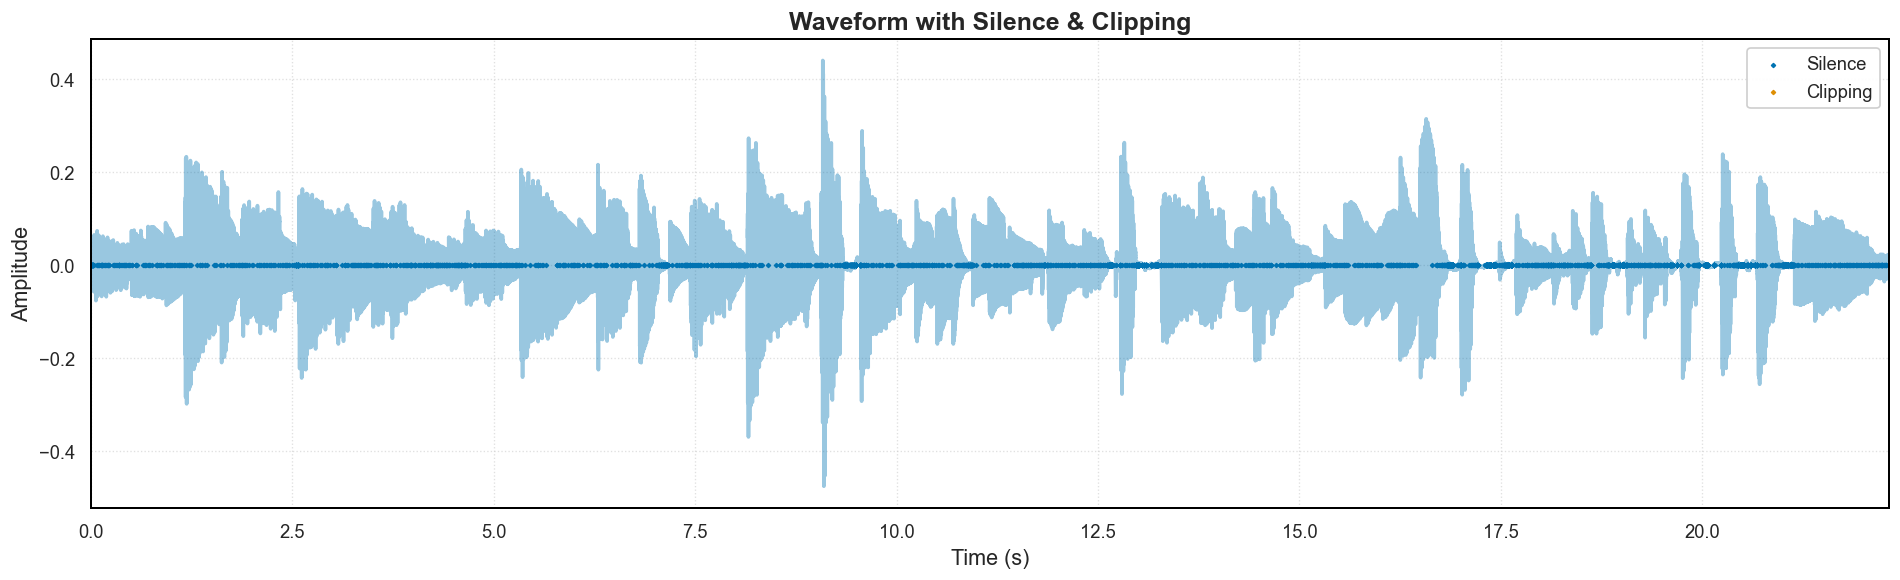

In [47]:
plt.figure(figsize=(16, 5))

plt.plot(time_audio, audio_data, alpha=0.4)

plt.scatter(silence_times, audio_data[silence], s=3, marker="x", label="Silence")
plt.scatter(clipping_times, audio_data[clipping], s=3, marker="x", label="Clipping")
plt.xlim(0, silence_times.max())

plt.legend()
plt.title("Waveform with Silence & Clipping")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "waveform_silence_clipping.png").as_posix())
plt.show()

Observation :
- Audio propre, peu de silence et de clipping.

### Etude de la qualité des audios

In [48]:
def analyze_silence_and_clipping(
    audio_data,
    sample_rate,
    silence_threshold=1e-4,
    clipping_threshold=0.99,
    silence_warning=20.0,
    silence_critical=60.0,
    clipping_warning=1.0,
    clipping_critical=10.0,
):
    def indices_to_segments(indices):
        if len(indices) == 0:
            return []

        splits = np.where(np.diff(indices) > 1)[0] + 1
        groups = np.split(indices, splits)

        return [(g[0] / sample_rate, g[-1] / sample_rate) for g in groups]

    # SILENCE
    silence_idx = np.where(np.abs(audio_data) < silence_threshold)[0]
    silence_ratio = len(silence_idx) / len(audio_data) * 100
    silence_segments = indices_to_segments(silence_idx)

    # DIAGNOSTIC
    if silence_ratio > silence_critical:
        silence_status = "mostly_silent"
    elif silence_ratio > silence_warning:
        silence_status = "partially_silent"
    else:
        silence_status = "clean"

    # CLIPPING
    clipping_idx = np.where(np.abs(audio_data) >= clipping_threshold)[0]
    clipping_ratio = len(clipping_idx) / len(audio_data) * 100
    clipping_segments = indices_to_segments(clipping_idx)

    # DIAGNOSTIC
    if clipping_ratio > clipping_critical:
        clipping_status = "heavily_distorted"
    elif clipping_ratio > clipping_warning:
        clipping_status = "saturated"
    else:
        clipping_status = "clean"

    return {
        "silence_ratio": silence_ratio,
        "silence_status": silence_status,
        "silence_segments": silence_segments,
        "silence_count": len(silence_segments),
        "clipping_ratio": clipping_ratio,
        "clipping_segments": clipping_segments,
        "clipping_count": len(clipping_segments),
        "clipping_status": clipping_status,
        "silence_indices": silence_idx,
        "clipping_indices": clipping_idx,
    }


audio_analysis = []

for obj in audio_mono_pickup_mix_objects:
    audio_data, sample_rate = minio.get_audio(
        bucket_name=MINIO_SETTINGS.bucket_raw,
        file_name=obj.object_name,
    )
    results = analyze_silence_and_clipping(audio_data, sample_rate)
    results["title"] = obj.object_name.split("/")[1]
    audio_analysis.append(
        {
            "title": obj.object_name.split("/")[1],
            "silence_ratio": results["silence_ratio"],
            "silence_status": results["silence_status"],
            "clipping_ratio": results["clipping_ratio"],
            "clipping_status": results["clipping_status"],
        }
    )

audio_analysis_df = pd.DataFrame(audio_analysis)

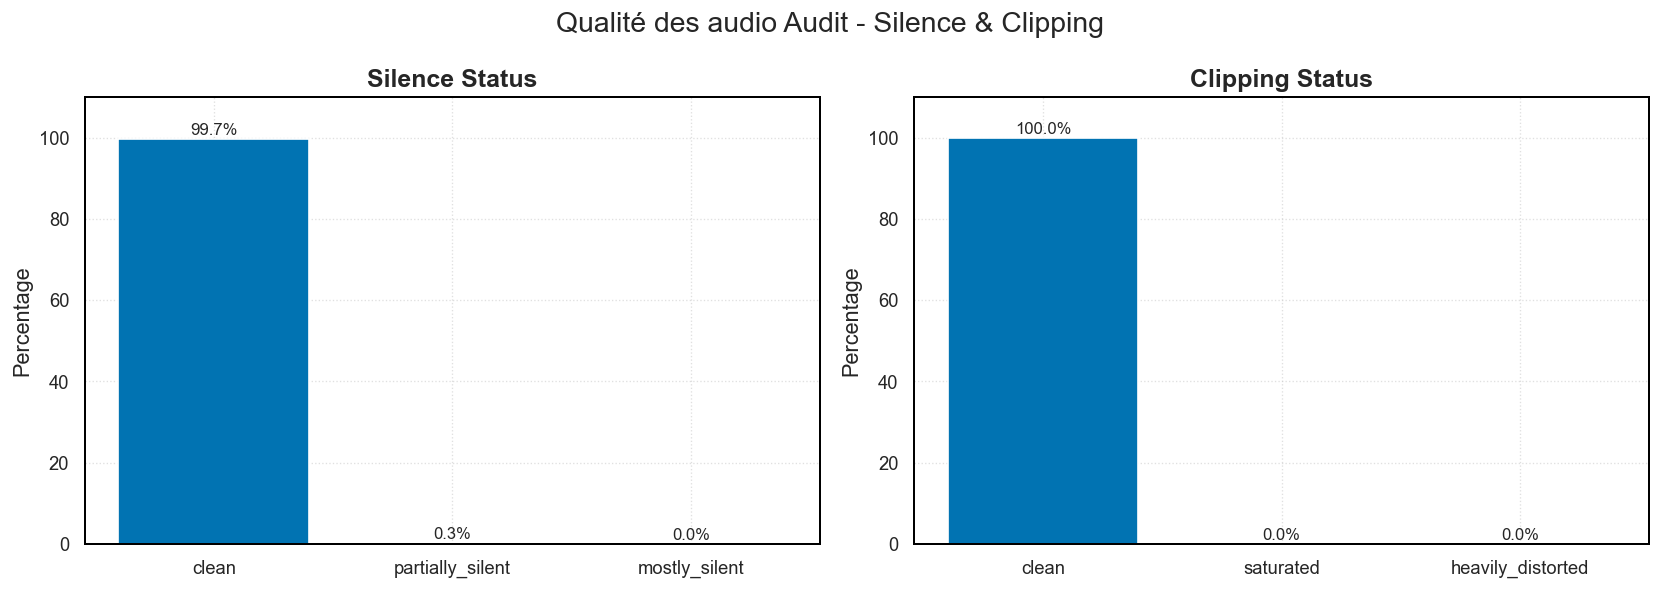

In [49]:
silence_order = ["clean", "partially_silent", "mostly_silent"]
clipping_order = ["clean", "saturated", "heavily_distorted"]

silence_counts = (
    audio_analysis_df["silence_status"]
    .value_counts()
    .reindex(silence_order, fill_value=0)
)
clipping_counts = (
    audio_analysis_df["clipping_status"]
    .value_counts()
    .reindex(clipping_order, fill_value=0)
)

silence_counts_norm = silence_counts / silence_counts.sum() * 100
clipping_counts_norm = clipping_counts / clipping_counts.sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Qualité des audio Audit - Silence & Clipping", fontsize=17)

bars1 = ax1.bar(silence_counts_norm.index, silence_counts_norm.values)

ax1.set_title("Silence Status")
ax1.set_ylabel("Percentage")
ax1.set_ylim(0, 110)

for bar in bars1:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2, h + 1, f"{h:.1f}%", ha="center", fontsize=10
    )

bars2 = ax2.bar(clipping_counts_norm.index, clipping_counts_norm.values)

ax2.set_title("Clipping Status")
ax2.set_ylabel("Percentage")
ax2.set_ylim(0, 110)

for bar in bars2:
    h = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2, h + 1, f"{h:.1f}%", ha="center", fontsize=10
    )

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "audio_silence_clipping.png").as_posix())
plt.show()

Observations :
- Les audio sont propores, peu de silence et pas de distortion.